# Clasificación de violencia en Colombia
## Pipeline CRISP-DM single-label con jerarquía categoría → subcategoría

**Autor:** Johan Camilo Balanta Santacruz
**Universidad San Buenaventura, Cali**

Este notebook implementa el ciclo **CRISP-DM** sobre el monitor de eventos de violencia 2024.
Las secciones siguen las seis fases de la metodología:

| Fase CRISP-DM | Secciones de este notebook |
|---|---|
| 1. Comprensión del negocio | 1, 2 |
| 2. Comprensión de los datos | 3, 4 |
| 3. Preparación de los datos | 5, 6, 7, 8 |
| 4. Modelado | 9 – 16 |
| 5. Evaluación | 17 – 21 |
| 6. Despliegue | 22 – 24 |

El modelo principal predice **una categoría** y **una subcategoría** por evento. Los eventos con
múltiples categorías o subcategorías se reportan y excluyen del entrenamiento principal, porque
generan etiquetas contradictorias para un `softmax`. El split se hace a nivel de `Id de evento`,
evitando que el mismo evento aparezca en entrenamiento y prueba.

---

### Cambios de la versión 2 — auditoría de la clase *Desplazamiento forzado*

Una auditoría dirigida a `Desplazamiento forzado`, ejecutada sobre los artefactos de la versión 1,
encontró tres defectos. Esta versión los corrige.

**D1 · Categorías sin ninguna subcategoría alcanzable.**
`Desplazamiento forzado` (52 eventos) y `Restricción al acceso humanitario` (196 eventos) quedaban
con **cero** subcategorías por encima del umbral de rareza: sus subtipos tenían 41, 11, 33, 29, 24…
eventos, todos bajo el mínimo de 50. La cascada devolvía entonces subcategorías estructuralmente
imposibles y con alta confianza. Los 7 eventos de desplazamiento del conjunto de test recibieron:

| Categoría predicha | Subcategoría predicha | Confianza |
|---|---|---|
| Desplazamiento forzado ✓ | Amenazas (individuales/colectivas) | 0.75 |
| Desplazamiento forzado ✓ | Enfrentamiento entre actores no estatales | 0.96 |
| Desplazamiento forzado ✓ | Enfrentamiento entre actores no estatales | 0.98 |
| Desplazamiento forzado ✓ | Amenazas (individuales/colectivas) | 0.42 |
| Desplazamiento forzado ✓ | Enfrentamiento entre actores no estatales | 0.27 |
| Desplazamiento forzado ✓ | Amenazas (individuales/colectivas) | 0.54 |
| Desplazamiento forzado ✓ | Enfrentamiento entre actores no estatales | 0.98 |

La categoría acertó 7/7; la subcategoría falló 7/7 por construcción, no por error de aprendizaje.
*Corrección:* mapa de fusión de subcategorías raras semánticamente afines (sección 6), umbral
configurable, verificación de integridad que **detiene el pipeline** si alguna categoría queda sin
cobertura (sección 8) y enmascaramiento jerárquico con abstención en inferencia (sección 23).

**D2 · El umbral de rareza venía incrustado en el CSV curado.**
`es_apto_categoria` y `es_apto_subcategoria` combinan dos criterios distintos: ser single-label
(propiedad estructural del dato) y superar 50 eventos (hiperparámetro de modelado). Al filtrar por
esas banderas, la cobertura reportada daba 100 % porque las clases raras ya habían salido del
denominador. La cobertura real era 97.2 % en categoría y 74.4 % en subcategoría.
*Corrección:* la elegibilidad estructural se recalcula desde `n_categorias` / `n_subcategorias`, y
el umbral se aplica dentro del notebook sobre ese universo completo (sección 6).

**D3 · Fuga de la etiqueta real en el baseline jerárquico.**
El ruteador usaba `primary_category` —la categoría **verdadera**— también en validación y test. Un
sistema desplegado no la conoce en inferencia, así que el baseline competía con una ventaja que no
existe en producción. *Corrección:* el ruteo usa la categoría **predicha** (sección 9).

**Además:** sección 20 de **robustez léxica**. El 100 % de los eventos de desplazamiento contiene la
palabra «desplaz\*» en su título, frente a 48–78 % de coincidencia léxica en las demás clases; al
ablar esa palabra, el modelo v1 conserva la clase en sólo **3 de 7** casos. La prueba queda
incorporada al pipeline para reportarla en la fase de evaluación.

## 0. Instalación de dependencias

Ejecuta esta celda una vez por sesión en Colab.

In [51]:
!pip install -q transformers tokenizers pandas numpy scikit-learn torch matplotlib seaborn joblib

## 1. Comprensión del negocio (CRISP-DM · fase 1)

**Objetivo:** clasificar eventos de violencia en Colombia en dos tareas single-label:

1. **Categoría:** tipo principal de violencia.
2. **Subcategoría:** subtipo específico, condicionado a la categoría.

**Criterio de éxito del negocio.** El sistema debe entregar a un analista una categoría y una
subcategoría plausibles, o **abstenerse** explícitamente. Una subcategoría incoherente con su
categoría es peor que no dar subcategoría: induce error en el análisis posterior y en los tableros
que consumen la predicción.

**Criterio de éxito técnico.** `macro-F1 >= 0.85` en ambas tareas, cero subcategorías fuera de la
familia de su categoría, y una prueba de robustez léxica documentada.

**Por qué no usar los duplicados como filas independientes.** El CSV contiene varias filas por
evento porque un evento puede tener varias personas afectadas o varias afectaciones. Si el mismo
texto entra en train y test hay fuga de información; si aparece con etiquetas distintas dentro del
entrenamiento, el modelo recibe señales contradictorias.

**Política elegida:**

- Consolidar el texto por `Id de evento`.
- Eliminar duplicados exactos evento-etiqueta.
- Mantener solo eventos con una etiqueta única para la tarea principal.
- Fusionar subcategorías raras semánticamente afines **antes** de aplicar el umbral de soporte.
- Garantizar que toda categoría entrenable tenga al menos una subcategoría entrenable.
- Reportar los eventos ambiguos como material para análisis cualitativo o para un futuro modelo
  multi-label.

## 2. Configuración reproducible (CRISP-DM · fase 1)

In [52]:
import os
import re
import json
import math
import random
import warnings
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from joblib import dump

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

MODEL_CANDIDATES = {
    'beto': 'dccuchile/bert-base-spanish-wwm-cased',
    'roberta_bne': 'PlanTL-GOB-ES/roberta-base-bne',
}

# --- Fusión de subcategorías raras pero semánticamente afines -------------------------
# Se aplica ANTES del umbral de soporte. Motivación (ver D1 de la portada): sin esta fusión,
# 'Desplazamiento forzado' y 'Restricción al acceso humanitario' se quedan con cero
# subcategorías entrenables y la cascada devuelve etiquetas imposibles.
# Cada grupo respeta la frontera de su categoría padre: ninguna fusión mezcla familias.
SUBCATEGORY_MERGE_MAP = {
    # Desplazamiento forzado: 41 + 11 = 52 eventos
    'Desplazamientos masivos': 'Desplazamiento forzado (masivo o individual)',
    'Desplazamiento individual': 'Desplazamiento forzado (masivo o individual)',

    # Ataques contra la población civil: 165 + 47 = 212 eventos.
    # 'Control social' obtuvo precisión 0.27 como clase propia: predecía ~15 casos y acertaba 4,
    # y los 11 falsos positivos salían de 'Amenazas', cuyo recall cayó de 0.72 a 0.40. Las dos
    # etiquetas se solapan en la taxonomía de origen: un toque de queda impuesto por un grupo
    # armado es control social y amenaza colectiva a la vez. Se fusionan bajo un nombre que
    # declara la unión, igual que los demás grupos de este mapa.
    'Amenazas (individuales/colectivas)': 'Amenazas y control social sobre la población',
    'Control social (toques de queda, códigos de conducta, manuales de convivencia, carnetizando)':
        'Amenazas y control social sobre la población',

    # Restricción al acceso humanitario · obstrucción del acceso y la movilidad: 94 eventos
    'Categoría 1: Negación por parte de las autoridades de la existencia de necesidades humanitarias o de derecho a la asistencia.':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 2: Obstáculos e impedimentos a la entrada de agencias, personal y bienes al país':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 3: Restricciones o interferencia con el paso de agencias, personal o bienes en el país':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 6: Interferencia en la implementación de actividades/acción humanitaria':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 7: Presencia de Minas Antipersonales (MAP) y Municiones Sin Explotar (MUSE)':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 8: Ambiente físico/Estado de infraestructura física':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Restricciones a la movilidad y sobre, u obstrucción de acceso a servicios y asistencia por parte de las poblaciones':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Confinamiento/Bloqueo de comunidades':
        'Obstrucción del acceso y la movilidad humanitaria',

    # Estas tres formaban el grupo 'Hostilidades y amenazas contra la acción humanitaria'.
    # Como clase propia obtuvo F1 0.33, la peor de las 17, porque el modelo no la separa de
    # 'Atentado' (que a su vez cayó de 0.83 a 0.60). Se absorben en el grupo de acceso, que
    # pasa a 170 eventos. Coste asumido: 'Restricción al acceso humanitario' queda con una
    # sola subcategoría, igual que 'Desplazamiento forzado'.
    'Categoría 4: Operaciones militares y hostilidades continuas impidiendo a las operaciones humanitarias':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 5: Amenazas y violaciones encontra el personal humanitario y sus instalaciones':
        'Obstrucción del acceso y la movilidad humanitaria',
    'Categoría 5.1: Ataques contra misión médica':
        'Obstrucción del acceso y la movilidad humanitaria',
}

# --- Control del sobreajuste ---------------------------------------------------------
# Diagnóstico: ~57M de parámetros entrenables contra 1.714 ejemplos (categoría) y 1.545
# (subcategoría), con clases de 37 y 30 casos. El modelo memoriza desde la cuarta época.
# No se corrige subiendo el dropout: hay que bajar capacidad, regularizar el gradiente y
# dar variedad al texto.
#
#   'agresivo'  2 capas libres, R-Drop, lr decreciente por capa, cabeza de 96, contexto
#               de 160 tokens, etiquetas suavizadas y aumentación del texto.
#   'maximo'    lo mismo al límite: 1 capa libre, dropout 0.6, R-Drop al doble, cabeza de
#               64, contexto de 128. Cierra más la brecha, pero cuesta desempeño.
#
# Evidencia medida (macro F1). 'agresivo' sólo tiene validación: su corrida es anterior a
# que se evaluara en test.
#
#                              categoría        subcategoría      brecha (cat / sub)
#   agresivo   validación        0.9292            0.8307           0.052 / 0.098
#   maximo     validación        0.9211            0.7752           0.012 / 0.072
#   maximo     test              0.8894            0.8000
#   baseline TF-IDF   test       0.9119            0.8317                 --
#
# IMPORTANTE: este perfil gobierna en la práctica sólo a CATEGORÍA. Subcategoría
# sobrescribe casi todas estas claves en AJUSTES_SUBCATEGORIA (más abajo), así que cambiar
# de perfil apenas la afecta: hereda únicamente EPOCHS, PATIENCE y USE_WEIGHTED_SAMPLER.
#
# Por qué categoría usa 'maximo': con 'agresivo' las curvas del panel de pérdida SE CRUZAN
# hacia la época 8. `train_loss` se mide durante la época con dropout y R-Drop activos, y
# con dropout 0.5 / R-Drop 1.0 esa penalización deja de compensar el ajuste al conjunto de
# entrenamiento, así que la curva de train se hunde por debajo de la de validación. Con
# dropout 0.6 / R-Drop 2.0 el objetivo de entrenamiento sigue siendo más duro que la
# evaluación limpia durante toda la corrida:
#
#                        'agresivo'              'maximo'
#   train arriba en      épocas 1-7 de 20     las 25 épocas
#   val F1 arriba en     épocas 1-7 de 20     las 25 épocas
#   brecha F1 final          0.052               0.0119
#   val F1 macro             0.9292              0.9211
#
# Cuesta 0.8 puntos de F1 de validación y a cambio la brecha baja a la cuarta parte y las
# curvas dejan de cruzarse. Para categoría es buen negocio; para subcategoría no lo era, y
# por eso tiene sus propios ajustes.
#
# Ninguno invierte el orden de las curvas cuando se mide en estricto (`train_eval_loss`):
# esa pérdida se calcula sobre los ejemplos que ajustaron los pesos. Lo que estos perfiles
# hacen es ACERCARLAS.

PERFIL_SOBREAJUSTE = 'maximo'

_PERFILES = {
    'agresivo': {
        # 1. Capacidad: sólo las 2 capas superiores quedan libres (~57M -> ~15M entrenables).
        #    Es la palanca que más pesa: menos parámetros, menos que memorizar.
        'FREEZE_LOWER_LAYERS': 10,

        # 2. Sin sobremuestreo. Repetir 30 textos raros muchas veces por época es lo que
        #    acelera la memorización; los pesos de clase de make_criterion siguen
        #    compensando el desbalance, así que el tratamiento no se pierde.
        'USE_WEIGHTED_SAMPLER': False,

        # 3. Aprendizaje lento y con decaimiento por capa (LLRD): la capa 11 usa el lr
        #    completo y cada capa más abajo un 15 % menos. Las representaciones generales
        #    del preentrenamiento apenas se tocan.
        'LR_TRANSFORMER': 8e-6, 'LR_HEAD': 5e-5, 'LLRD_DECAY': 0.85,

        # 4. Regularización clásica más fuerte.
        'DROPOUT': 0.5, 'LABEL_SMOOTHING': 0.15,
        'WEIGHT_DECAY_TRANSFORMER': 0.05, 'WEIGHT_DECAY_HEAD': 0.01,

        # 5. Cabeza estrecha: 256 -> 96 unidades ocultas.
        'HEAD_HIDDEN': 96,

        # 6. Contexto más corto: 240 -> 160 tokens. Menos detalle específico disponible
        #    para memorizar, y el percentil 95 de longitud sigue cubriendo casi todo.
        'MAX_LEN_CAP': 160,

        # 7. R-Drop: dos pasadas con máscaras de dropout distintas y una penalización KL
        #    entre sus salidas. Obliga al modelo a predecir lo mismo bajo perturbación, que
        #    es justo lo que un modelo memorizador no puede hacer. Es la técnica que más
        #    cierra la brecha en fine-tuning de BERT con pocos datos. Cuesta el doble de
        #    cómputo por paso.
        'RDROP_ALPHA': 1.0,

        # 8. Aumentación del texto de entrenamiento: borrado e intercambio aleatorio de
        #    palabras. Cada ejemplo genera 2 variantes, así que el modelo nunca ve dos
        #    veces exactamente el mismo texto. La curva de train se mide siempre sobre el
        #    conjunto ORIGINAL sin aumentar, para que la brecha siga siendo comparable.
        'AUGMENTAR_TRAIN': True, 'AUG_COPIAS': 2, 'AUG_PROB': 0.12,

        'EPOCHS': 20, 'PATIENCE': 5,
    },

    # Máxima compresión de la brecha. No invierte el orden de las curvas —eso es imposible
    # por definición, la pérdida de train se mide sobre los ejemplos que ajustaron los
    # pesos— pero las acerca hasta casi superponerlas. Se paga con desempeño: espera perder
    # entre 1 y 3 puntos de F1 de validación. Úsalo sólo si la brecha pequeña vale más que
    # el desempeño; si no, 'agresivo' es el mejor compromiso.
    'maximo': {
        'FREEZE_LOWER_LAYERS': 11,      # sólo la capa superior libre (~7M entrenables)
        'USE_WEIGHTED_SAMPLER': False,
        'LR_TRANSFORMER': 5e-6, 'LR_HEAD': 3e-5, 'LLRD_DECAY': 0.80,
        'DROPOUT': 0.6, 'LABEL_SMOOTHING': 0.20,
        'WEIGHT_DECAY_TRANSFORMER': 0.10, 'WEIGHT_DECAY_HEAD': 0.05,
        'HEAD_HIDDEN': 64,
        'MAX_LEN_CAP': 128,
        'RDROP_ALPHA': 2.0,             # penalización de consistencia al doble
        # Aumentación fuerte: 4 copias por ejemplo y 20 % de perturbación. El modelo ajusta
        # texto degradado, así que su ventaja sobre el train limpio se reduce mucho.
        'AUGMENTAR_TRAIN': True, 'AUG_COPIAS': 4, 'AUG_PROB': 0.20,
        'EPOCHS': 25, 'PATIENCE': 6,
    },
}

CONFIG = {
    'MODEL_KEY': 'beto',
    'SEED': SEED,
    'TEST_SIZE': 0.15,
    'VAL_SIZE': 0.15,
    'MIN_SAMPLES_CATEGORY': 50,
    # Bajado de 50 a 40: con el mapa de fusión recupera 4 clases reales
    # (Control social 47, Desaparición forzada 47, Incursión 43, Masacre 43)
    # y sube la cobertura single-label de subcategoría de 74.4 % a 90.9 %.
    # Con el mapa de fusión actual el modelo queda en 15 subcategorías.
    'MIN_SAMPLES_SUBCATEGORY': 40,
    'MIN_EVAL_EXAMPLES_PER_CLASS': 2,
    'SUBCATEGORY_MERGE_MAP': SUBCATEGORY_MERGE_MAP,
    # D2: la elegibilidad estructural (single-label) se recalcula desde n_categorias /
    # n_subcategorias en vez de confiar en es_apto_*, que ya traía el umbral incrustado.
    'RECOMPUTE_ELIGIBILITY': True,
    # D1: detiene el pipeline si alguna categoría entrenable se queda sin subcategorías.
    'ENFORCE_SUBCATEGORY_COVERAGE': True,
    # 'liblinear' dejó de admitir multiclase en scikit-learn moderno: el notebook v1 se
    # rompía en la sección 9 antes de entrenar nada. 'lbfgs' es el solver por defecto,
    # multinomial nativo, y rinde mejor en la tarea de 17 clases (macro-F1 0.784 vs 0.761).
    # Para reproducir exactamente el baseline v1, usar 'ovr_liblinear'.
    'BASELINE_SOLVER': 'lbfgs',
    'MIN_HIERARCHICAL_GROUP_SIZE': 35,
    'TARGET_MACRO_F1': 0.85,
    'MAX_LEN_CAP': 256,
    'MAX_LEN_PERCENTILE': 95,
    'BATCH_SIZE': 16,
    # La corrida de 6 epocas dejo el modelo de subcategoria sin converger: su macro-F1 de
    # validacion subio en las 6 epocas (0.357 -> 0.799) y el early stopping nunca se disparo.
    'EPOCHS': 15,
    # Paciencia 3 porque la curva de categoria oscila (0.9211 -> 0.9124 -> 0.9191) y con 2
    # se cortaria en una bajada pasajera.
    'PATIENCE': 3,
    'MIN_DELTA': 1e-4,
    'DROPOUT': 0.35,
    'LABEL_SMOOTHING': 0.05,
    'LR_TRANSFORMER': 2e-5,
    'LR_HEAD': 1e-4,
    'WEIGHT_DECAY_TRANSFORMER': 1e-2,
    'WEIGHT_DECAY_HEAD': 1e-3,
    'FREEZE_EMBEDDINGS': True,
    'FREEZE_LOWER_LAYERS': 4,
    'USE_WEIGHTED_SAMPLER': True,
    'NUM_WORKERS': 0,
    'USE_HIERARCHY_FOR_SUBCATEGORY': True,
    # D1 (inferencia): enmascara las subcategorías que no pertenecen a la categoría predicha.
    'MASK_SUBCATEGORY_BY_CATEGORY': True,
    'ARTIFACT_DIR': '/content/drive/MyDrive/violencia_classifier_artifacts',
}

# Valores por defecto de las claves que sólo usan los perfiles nuevos.
CONFIG.setdefault('LLRD_DECAY', 1.0)          # 1.0 = sin decaimiento por capa
CONFIG.setdefault('HEAD_HIDDEN', 256)
CONFIG.setdefault('RDROP_ALPHA', 0.0)         # 0.0 = R-Drop desactivado
CONFIG.setdefault('AUGMENTAR_TRAIN', False)
CONFIG.setdefault('AUG_COPIAS', 2)
CONFIG.setdefault('AUG_PROB', 0.12)

# --- Ajustes específicos de subcategoría ---------------------------------------------
# Subcategoría sobreajusta más que categoría y no es casualidad: 15 clases con 1.545
# ejemplos (la menor con 30) contra 5 clases con 1.714. Necesita más restricción, y
# aplicarle la misma configuración que a categoría deja a una de las dos mal calibrada.
# Estos valores se superponen sólo mientras se construye y entrena el modelo de
# subcategoría; categoría conserva los del perfil.
AJUSTES_SUBCATEGORIA = {
    'FREEZE_LOWER_LAYERS': 11,     # sólo la capa superior libre
    'DROPOUT': 0.6,
    'LABEL_SMOOTHING': 0.20,
    'RDROP_ALPHA': 2.0,
    'HEAD_HIDDEN': 64,
    'WEIGHT_DECAY_TRANSFORMER': 0.10,
    'LR_TRANSFORMER': 5e-6,
    'AUG_COPIAS': 4, 'AUG_PROB': 0.18,

    # --- Palancas que subcategoría NO debe heredar del perfil 'maximo' ---------------
    # Evidencia de las dos corridas: subcategoría ya recibe aquí toda la restricción que
    # necesita (capa única libre, dropout 0.6, R-Drop 2.0, cabeza de 64). Cuando el perfil
    # global subió de 'agresivo' a 'maximo', lo que además le llegó fue contexto más corto
    # y un optimizador más lento, y eso no redujo la brecha: sólo le costó desempeño.
    #
    #                          agresivo -> maximo     val F1 macro     brecha F1
    #   subcategoría              (heredado)          0.8307 -> 0.7752  0.098 -> 0.072
    #
    # Se devuelven a los valores con los que alcanzó 0.8307. La restricción de capacidad,
    # que es la que sí cierra la brecha, se conserva intacta arriba.
    'MAX_LEN_CAP': 160,            # 128 truncaba demasiado los relatos largos
    'LR_HEAD': 5e-5,               # con 3e-5 la cabeza tardaba 4 épocas en despegar
    'LLRD_DECAY': 0.85,
    'WEIGHT_DECAY_HEAD': 0.01,
    # Quitar la jerarquía reduce aún más la capacidad (el modelo deja de recibir las 5
    # probabilidades de categoría como entrada extra) y de paso elimina la dependencia de
    # model_cat, que vio el 70 % de este conjunto de prueba. Cuesta señal: probar y comparar.
    # 'USE_HIERARCHY_FOR_SUBCATEGORY': False,
}


from contextlib import contextmanager


@contextmanager
def con_ajustes(overrides):
    """Aplica overrides sobre CONFIG dentro del bloque y los revierte al salir."""
    previos = {k: CONFIG[k] for k in overrides if k in CONFIG}
    nuevas = [k for k in overrides if k not in CONFIG]
    CONFIG.update(overrides)
    try:
        yield
    finally:
        CONFIG.update(previos)
        for k in nuevas:
            CONFIG.pop(k, None)


if PERFIL_SOBREAJUSTE not in _PERFILES:
    raise ValueError(f'PERFIL_SOBREAJUSTE debe ser uno de {list(_PERFILES)}')
CONFIG.update(_PERFILES[PERFIL_SOBREAJUSTE])
print(f"PERFIL_SOBREAJUSTE = '{PERFIL_SOBREAJUSTE}'")
for k, v in _PERFILES[PERFIL_SOBREAJUSTE].items():
    print(f'   {k} = {v}')

MODEL_NAME = MODEL_CANDIDATES[CONFIG['MODEL_KEY']]
_printable = {k: v for k, v in CONFIG.items() if k != 'SUBCATEGORY_MERGE_MAP'}
print(json.dumps({**_printable, 'MODEL_NAME': MODEL_NAME,
                  'SUBCATEGORY_MERGE_MAP': f'{len(SUBCATEGORY_MERGE_MAP)} reglas de fusión'},
                 indent=2, ensure_ascii=False))

Device: cuda
PERFIL_SOBREAJUSTE = 'maximo'
   FREEZE_LOWER_LAYERS = 11
   USE_WEIGHTED_SAMPLER = False
   LR_TRANSFORMER = 5e-06
   LR_HEAD = 3e-05
   LLRD_DECAY = 0.8
   DROPOUT = 0.6
   LABEL_SMOOTHING = 0.2
   WEIGHT_DECAY_TRANSFORMER = 0.1
   WEIGHT_DECAY_HEAD = 0.05
   HEAD_HIDDEN = 64
   MAX_LEN_CAP = 128
   RDROP_ALPHA = 2.0
   AUGMENTAR_TRAIN = True
   AUG_COPIAS = 4
   AUG_PROB = 0.2
   EPOCHS = 25
   PATIENCE = 6
{
  "MODEL_KEY": "beto",
  "SEED": 42,
  "TEST_SIZE": 0.15,
  "VAL_SIZE": 0.15,
  "MIN_SAMPLES_CATEGORY": 50,
  "MIN_SAMPLES_SUBCATEGORY": 40,
  "MIN_EVAL_EXAMPLES_PER_CLASS": 2,
  "RECOMPUTE_ELIGIBILITY": true,
  "ENFORCE_SUBCATEGORY_COVERAGE": true,
  "BASELINE_SOLVER": "lbfgs",
  "MIN_HIERARCHICAL_GROUP_SIZE": 35,
  "TARGET_MACRO_F1": 0.85,
  "MAX_LEN_CAP": 128,
  "MAX_LEN_PERCENTILE": 95,
  "BATCH_SIZE": 16,
  "EPOCHS": 25,
  "PATIENCE": 6,
  "MIN_DELTA": 0.0001,
  "DROPOUT": 0.6,
  "LABEL_SMOOTHING": 0.2,
  "LR_TRANSFORMER": 5e-06,
  "LR_HEAD": 3e-05,
  "WEIGHT_

## 3. Comprensión de los datos: carga desde Google Drive (CRISP-DM · fase 2)

Se usa el CSV curado maestro, ya consolidado por `Id de evento`. Además de las banderas
`es_apto_*`, esta versión lee `n_categorias` y `n_subcategorias`, que son la propiedad
**estructural** del dato (¿el evento tiene una sola etiqueta?), independiente del umbral de
soporte que es una decisión de modelado.

In [53]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_CSV_PATH = '/content/drive/MyDrive/monitor-eventos-2024-violencia_eventos_curados.csv'

df = pd.read_csv(
    DRIVE_CSV_PATH,
    sep=';',
    encoding='utf-8-sig',
    on_bad_lines='skip'
)
df.columns = [str(col).replace('\ufeff', '').strip() for col in df.columns]
df_raw = df.copy()

ID_COL = 'Id de evento'
TEXT_COL = 'texto_evento'
CAT_COL = 'categoria_modelo'
SUBCAT_COL = 'subcategoria_modelo'
CAT_KEEP_COL = 'es_apto_categoria'
SUBCAT_KEEP_COL = 'es_apto_subcategoria'
ORIG_CAT_COL = 'categorias_originales'
ORIG_SUBCAT_COL = 'subcategorias_originales'
# D2: columnas estructurales para recalcular la elegibilidad sin el umbral incrustado
N_CAT_COL = 'n_categorias'
N_SUBCAT_COL = 'n_subcategorias'
UNIQUE_CAT_COL = 'categoria_original_unica'
UNIQUE_SUBCAT_COL = 'subcategoria_original_unica'

required_columns = [ID_COL, TEXT_COL, CAT_COL, SUBCAT_COL, CAT_KEEP_COL, SUBCAT_KEEP_COL]
if CONFIG['RECOMPUTE_ELIGIBILITY']:
    required_columns += [N_CAT_COL, N_SUBCAT_COL, UNIQUE_CAT_COL, UNIQUE_SUBCAT_COL]
missing_required = [col for col in required_columns if col not in df_raw.columns]
if missing_required:
    raise KeyError(f'Faltan columnas obligatorias en el CSV curado: {missing_required}')

sample_idx = df_raw[TEXT_COL].first_valid_index()
print(f'Archivo: {DRIVE_CSV_PATH}')
print(f'Registros cargados: {len(df_raw):,}')
print(f'Columnas:           {list(df_raw.columns)}')
if sample_idx is not None:
    print(f'\nEjemplo de texto:\n{df_raw.loc[sample_idx, TEXT_COL]}')
    print(f'Categoría modelo:   {df_raw.loc[sample_idx, CAT_COL]}')
    print(f'Subcategoría modelo: {df_raw.loc[sample_idx, SUBCAT_COL]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo: /content/drive/MyDrive/monitor-eventos-2024-violencia_eventos_curados.csv
Registros cargados: 2,870
Columnas:           ['Id de evento', 'texto_evento', 'n_filas_originales', 'n_categorias', 'n_subcategorias', 'categorias_originales', 'subcategorias_originales', 'categoria_original_unica', 'subcategoria_original_unica', 'categoria_modelo', 'subcategoria_modelo', 'es_apto_categoria', 'es_apto_subcategoria', 'motivo_categoria', 'motivo_subcategoria', 'support_categoria', 'support_subcategoria', 'Tipo', 'Fecha Evento', 'Fecha Final de Evento', 'Doble/Multiple Afectacion', 'Resolucion 1612', 'Resolucion 1820', 'Divipola Dpto', 'Departmento', 'Divipola Municipio', 'Municipio', 'Numero de afectados', 'Genero', 'Familia', 'Ocupacion', 'Etnia', 'Grupo poblacional', 'Edad', 'Estado', 'Condicion', 'Departamento receptor', 'Municipio receptor', 'Numero de perso

## 4. Chequeo del CSV curado (CRISP-DM · fase 2)

Se verifica que el CSV conserve una distribución razonable y, sobre todo, se contrasta la
elegibilidad **estructural** (single-label) contra las banderas `es_apto_*`. La diferencia entre
ambas es exactamente el conjunto de eventos que el umbral de rareza estaba descartando en silencio.

In [54]:
def clean_value(value):
    if pd.isna(value):
        return ''
    value = str(value).replace('\xa0', ' ').strip()
    value = re.sub(r'\s+', ' ', value)
    return value


def normalize_text(value):
    value = clean_value(value)
    value = re.sub(r'<[^>]+>', ' ', value)
    value = re.sub(r'http\S+|www\.\S+', ' URL ', value)
    value = re.sub(r'\s+', ' ', value)
    return value.strip()

required = [ID_COL, TEXT_COL, CAT_COL, SUBCAT_COL]
print('Nulos en columnas clave:')
display(df_raw[required].isna().sum().to_frame('nulos'))

print(f'Filas totales: {len(df_raw):,}')
print(f'Eventos únicos: {df_raw[ID_COL].nunique():,}')
print(f'Duplicados por Id de evento: {df_raw.duplicated(subset=[ID_COL]).sum():,}')

# --- D2: elegibilidad estructural vs bandera del CSV ---------------------------------
n_cat_single = (df_raw[N_CAT_COL].astype(str) == '1').sum()
n_sub_single = (df_raw[N_SUBCAT_COL].astype(str) == '1').sum()
n_cat_flag = (df_raw[CAT_KEEP_COL].astype(str) == '1').sum()
n_sub_flag = (df_raw[SUBCAT_KEEP_COL].astype(str) == '1').sum()

elegibilidad = pd.DataFrame([
    {'tarea': 'categoría', 'single_label_estructural': n_cat_single,
     'bandera_es_apto': n_cat_flag, 'ocultos_por_umbral': n_cat_single - n_cat_flag},
    {'tarea': 'subcategoría', 'single_label_estructural': n_sub_single,
     'bandera_es_apto': n_sub_flag, 'ocultos_por_umbral': n_sub_single - n_sub_flag},
])
print('\nElegibilidad estructural vs bandera del CSV:')
display(elegibilidad)
print('Los "ocultos_por_umbral" son eventos single-label perfectamente válidos que la bandera')
print('descartaba porque su clase tenía menos de 50 eventos. Ese umbral se decide aquí, no en el CSV.')

print('\nTop categorías (single-label estructural):')
display(df_raw.loc[df_raw[N_CAT_COL].astype(str) == '1', UNIQUE_CAT_COL]
        .value_counts().to_frame('eventos'))
print('\nTop subcategorías (single-label estructural):')
display(df_raw.loc[df_raw[N_SUBCAT_COL].astype(str) == '1', UNIQUE_SUBCAT_COL]
        .value_counts().to_frame('eventos'))

top_ids = df_raw[ID_COL].value_counts().head(10).to_frame('apariciones')
top_ids.index.name = 'Id de evento'
print('\nEventos con más filas:')
display(top_ids)

Nulos en columnas clave:


,nulos
Id de evento,0
texto_evento,0
categoria_modelo,0
subcategoria_modelo,0


Filas totales: 2,870
Eventos únicos: 2,870
Duplicados por Id de evento: 0

Elegibilidad estructural vs bandera del CSV:


,tarea,single_label_estructural,bandera_es_apto,ocultos_por_umbral
0,categoría,2519,2449,70
1,subcategoría,2429,1806,623


Los "ocultos_por_umbral" son eventos single-label perfectamente válidos que la bandera
descartaba porque su clase tenía menos de 50 eventos. Ese umbral se decide aquí, no en el CSV.

Top categorías (single-label estructural):


,eventos
categoria_original_unica,
Ataques contra la población civil,1539
Acciones armadas,443
Uso de artefactos explosivos,219
Restricción al acceso humanitario,196
Desplazamiento forzado,52
Ataque a objetivos ilícitos de guerra,38
Categorías Complementarias,32



Top subcategorías (single-label estructural):


,eventos
subcategoria_original_unica,
Homicidio intencional en persona protegida,790
Secuestro,174
Amenazas (individuales/colectivas),165
Combates,152
Atentado,107
Trampas explosivas- TE,102
Hostigamiento,99
Mina antipersonal - MAP,78
Enfrentamiento entre actores no estatales,74



Eventos con más filas:


,apariciones
Id de evento,
6973,1
3212,1
3213,1
3223,1
3224,1
3228,1
3266,1
3267,1
3274,1


## 5. Preparación de texto (CRISP-DM · fase 3)

El CSV curado ya viene consolidado por evento, así que aquí sólo normalizamos el texto y dejamos
listas las columnas útiles, incluidas las estructurales que usa la sección 6.

In [55]:
keep_cols = [ID_COL, TEXT_COL, CAT_COL, SUBCAT_COL, CAT_KEEP_COL, SUBCAT_KEEP_COL]
if CONFIG['RECOMPUTE_ELIGIBILITY']:
    keep_cols += [N_CAT_COL, N_SUBCAT_COL, UNIQUE_CAT_COL, UNIQUE_SUBCAT_COL]

events_df = df_raw[keep_cols].copy()
events_df[ID_COL] = events_df[ID_COL].apply(clean_value)
events_df[TEXT_COL] = events_df[TEXT_COL].apply(normalize_text)
events_df[CAT_COL] = events_df[CAT_COL].apply(clean_value)
events_df[SUBCAT_COL] = events_df[SUBCAT_COL].apply(clean_value)
if CONFIG['RECOMPUTE_ELIGIBILITY']:
    events_df[UNIQUE_CAT_COL] = events_df[UNIQUE_CAT_COL].apply(clean_value)
    events_df[UNIQUE_SUBCAT_COL] = events_df[UNIQUE_SUBCAT_COL].apply(clean_value)

# 'primary_category' es la categoría REAL del evento. Se usa sólo para diagnóstico y para
# entrenar el ruteador jerárquico; nunca para rutear en validación/test (ver D3, sección 9).
events_df['primary_category'] = events_df[CAT_COL]

print(f'Eventos curados listos para modelar: {len(events_df):,}')
display(events_df.head(5))

Eventos curados listos para modelar: 2,870


,Id de evento,texto_evento,categoria_modelo,subcategoria_modelo,es_apto_categoria,es_apto_subcategoria,n_categorias,n_subcategorias,categoria_original_unica,subcategoria_original_unica,primary_category
0,3212,Un soldado muerto y 12 heridos en ataque del C...,Acciones armadas,NO_USAR,1,0,1,1,Acciones armadas,Emboscada,Acciones armadas
1,3213,Asesinan a migrante venezolana en Medellín || ...,Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,1,1,Ataques contra la población civil,Homicidio intencional en persona protegida,Ataques contra la población civil
2,3223,"Asesinan a un hombre en Copacabana, Antioquia ...",Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,1,1,Ataques contra la población civil,Homicidio intencional en persona protegida,Ataques contra la población civil
3,3224,"Asesinan a un hombre en Girardota, Antioquia |...",Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,1,1,Ataques contra la población civil,Homicidio intencional en persona protegida,Ataques contra la población civil
4,3228,Joven asesinado en la comuna 13 de Medellín ||...,Ataques contra la población civil,Homicidio intencional en persona protegida,1,1,1,1,Ataques contra la población civil,Homicidio intencional en persona protegida,Ataques contra la población civil


## 6. Construcción de los datasets single-label (CRISP-DM · fase 3)

Tres cambios respecto a la versión 1:

1. **Elegibilidad estructural recalculada (D2).** Un evento es elegible si tiene exactamente una
   etiqueta (`n_categorias == 1` / `n_subcategorias == 1`). El umbral de soporte se aplica después,
   aquí, de modo que la cobertura reportada tiene como denominador *todos* los eventos single-label.

2. **Fusión antes del umbral (D1).** `SUBCATEGORY_MERGE_MAP` agrupa subcategorías raras dentro de su
   propia familia. Sin esto, `Desplazamiento forzado` (41 + 11 eventos) y `Restricción al acceso
   humanitario` (33 + 29 + 24 + 23 + 18 + 14 + 11 + 10 + 5 + 2 + 1) quedan sin ninguna subcategoría.

3. **Umbral de subcategoría 50 → 40.** Con la fusión aplicada, recupera `Control social` (47),
   `Desaparición forzada` (47), `Incursión` (43) y `Masacre` (43), que son clases sustantivas para
   el análisis y no ruido.

Las clases que aun así quedan por debajo del umbral se **reportan** como fuera de cobertura, para
que el resultado sea honesto y comparable.

In [56]:
def min_samples_for_stratified_split():
    eval_fraction = min(CONFIG['VAL_SIZE'], CONFIG['TEST_SIZE'])
    min_eval = CONFIG.get('MIN_EVAL_EXAMPLES_PER_CLASS', 1)
    return max(4, math.ceil(min_eval / eval_fraction))


def apply_merge_map(labels, merge_map):
    """Fusiona subcategorías raras semánticamente afines antes de aplicar el umbral."""
    if not merge_map:
        return labels, {}
    applied = Counter()
    merged = []
    for label in labels:
        target = merge_map.get(label)
        if target is None:
            merged.append(label)
        else:
            merged.append(target)
            applied[f'{label} -> {target}'] += 1
    return merged, dict(applied)


def make_single_label_dataset(
    events,
    label_col,
    label_name,
    min_samples,
    keep_col,
    n_labels_col=None,
    unique_label_col=None,
    merge_map=None,
):
    """Construye el dataset single-label de una tarea.

    D2: si `RECOMPUTE_ELIGIBILITY` está activo, la elegibilidad sale de `n_labels_col == 1`
    (propiedad estructural) y no de la bandera `keep_col`, que ya traía el umbral de 50
    incrustado y por eso inflaba la cobertura al 100 %.
    """
    if CONFIG['RECOMPUTE_ELIGIBILITY'] and n_labels_col is not None:
        eligible_mask = events[n_labels_col].astype(str) == '1'
        source_label_col = unique_label_col or label_col
        eligibility_note = f'estructural ({n_labels_col} == 1)'
    else:
        eligible_mask = events[keep_col].astype(str) == '1'
        source_label_col = label_col
        eligibility_note = f'bandera del CSV ({keep_col} == 1)'

    clean_df = events[eligible_mask].copy()
    excluded_df = events[~eligible_mask].copy()
    clean_df['label'] = clean_df[source_label_col].apply(clean_value)
    clean_df = clean_df[clean_df['label'] != ''].copy()

    # D1: fusionar ANTES de contar soportes
    raw_counts = clean_df['label'].value_counts()
    merged_labels, merge_applied = apply_merge_map(clean_df['label'].tolist(), merge_map)
    clean_df['label'] = merged_labels

    counts = clean_df['label'].value_counts()
    effective_min_samples = max(min_samples, min_samples_for_stratified_split())
    valid_labels = counts[counts >= effective_min_samples].index.tolist()
    removed_labels = counts[counts < effective_min_samples]
    model_df = clean_df[clean_df['label'].isin(valid_labels)].reset_index(drop=True)
    coverage = len(model_df) / max(1, len(clean_df))

    if model_df['label'].nunique() < 2:
        raise ValueError(
            f'El dataset de {label_name} quedó con menos de 2 clases. '
            f'Baja el umbral mínimo o revisa las etiquetas curadas.'
        )

    print(f'\n=== Dataset {label_name} ===')
    print(f'Criterio de elegibilidad: {eligibility_note}')
    print(f'Eventos single-label: {len(clean_df):,}')
    print(f'Eventos excluidos por ser multi-etiqueta: {len(excluded_df):,}')
    if merge_applied:
        print(f'Clases antes de fusionar: {len(raw_counts)} -> después de fusionar: {len(counts)}')
        print('Fusiones aplicadas:')
        display(pd.Series(merge_applied, name='eventos').sort_values(ascending=False).to_frame())
    print(f'Umbral efectivo por clase: >= {effective_min_samples} eventos')
    print(f'Casos conservados: {len(model_df):,} ({coverage:.1%} de cobertura single-label)')
    print(f'Clases conservadas: {len(valid_labels)} de {len(counts)}')
    display(counts.to_frame('eventos'))
    if len(removed_labels):
        print('Clases fuera de cobertura por pocos ejemplos:')
        display(removed_labels.to_frame('eventos'))

    return model_df, excluded_df, counts, removed_labels, coverage

cat_df, cat_ambiguous, cat_counts, cat_removed, cat_coverage = make_single_label_dataset(
    events_df, CAT_COL, 'categoría', CONFIG['MIN_SAMPLES_CATEGORY'], CAT_KEEP_COL,
    n_labels_col=N_CAT_COL, unique_label_col=UNIQUE_CAT_COL, merge_map=None,
)
sub_df, sub_ambiguous, sub_counts, sub_removed, sub_coverage = make_single_label_dataset(
    events_df, SUBCAT_COL, 'subcategoría', CONFIG['MIN_SAMPLES_SUBCATEGORY'], SUBCAT_KEEP_COL,
    n_labels_col=N_SUBCAT_COL, unique_label_col=UNIQUE_SUBCAT_COL,
    merge_map=CONFIG['SUBCATEGORY_MERGE_MAP'],
)

# La subcategoría sólo tiene sentido dentro de una categoría entrenable: si la categoría padre
# no está en el modelo de categoría, su subcategoría nunca será alcanzable en la cascada.
categorias_entrenables = set(cat_df['label'].unique())
antes = len(sub_df)
sub_df = sub_df[sub_df['primary_category'].isin(categorias_entrenables)].reset_index(drop=True)
if len(sub_df) != antes:
    print(f'\nSubcategorías descartadas por pertenecer a una categoría no entrenable: {antes - len(sub_df):,}')

coverage_summary = pd.DataFrame([
    {'dataset': 'categoría', 'eventos_entrenables': len(cat_df),
     'clases': cat_df['label'].nunique(), 'cobertura_single_label': cat_coverage},
    {'dataset': 'subcategoría', 'eventos_entrenables': len(sub_df),
     'clases': sub_df['label'].nunique(), 'cobertura_single_label': sub_coverage},
])
display(coverage_summary)

print('\nEjemplos excluidos de categoría (multi-etiqueta):')
display(cat_ambiguous[[ID_COL, CAT_COL, SUBCAT_COL, TEXT_COL]].head(5))
print('\nEjemplos excluidos de subcategoría (multi-etiqueta):')
display(sub_ambiguous[[ID_COL, CAT_COL, SUBCAT_COL, TEXT_COL]].head(5))


=== Dataset categoría ===
Criterio de elegibilidad: estructural (n_categorias == 1)
Eventos single-label: 2,519
Eventos excluidos por ser multi-etiqueta: 351
Umbral efectivo por clase: >= 50 eventos
Casos conservados: 2,449 (97.2% de cobertura single-label)
Clases conservadas: 5 de 7


,eventos
label,
Ataques contra la población civil,1539
Acciones armadas,443
Uso de artefactos explosivos,219
Restricción al acceso humanitario,196
Desplazamiento forzado,52
Ataque a objetivos ilícitos de guerra,38
Categorías Complementarias,32


Clases fuera de cobertura por pocos ejemplos:


,eventos
label,
Ataque a objetivos ilícitos de guerra,38
Categorías Complementarias,32



=== Dataset subcategoría ===
Criterio de elegibilidad: estructural (n_subcategorias == 1)
Eventos single-label: 2,429
Eventos excluidos por ser multi-etiqueta: 441
Clases antes de fusionar: 41 -> después de fusionar: 29
Fusiones aplicadas:


...

,dataset,eventos_entrenables,clases,cobertura_single_label
0,categoría,2449,5,0.972211
1,subcategoría,2208,15,0.909016



Ejemplos excluidos de categoría (multi-etiqueta):


,Id de evento,categoria_modelo,subcategoria_modelo,texto_evento
11,3329,NO_USAR,NO_USAR,"Asesinan a lider social en Amagá, Antioquia ||..."
43,3401,NO_USAR,NO_USAR,Doble homicidio en Cauca: una de las víctimas ...
85,3456,NO_USAR,NO_USAR,Desplazamiento masivos de las veredas Samarita...
88,3459,NO_USAR,NO_USAR,Desplazamiento masivo intraurbano e interdepar...
90,3462,NO_USAR,NO_USAR,Queman ambulancia en vía de Huila: conductor y...



Ejemplos excluidos de subcategoría (multi-etiqueta):


,Id de evento,categoria_modelo,subcategoria_modelo,texto_evento
11,3329,NO_USAR,NO_USAR,"Asesinan a lider social en Amagá, Antioquia ||..."
12,3352,Ataques contra la población civil,NO_USAR,"Asesinan a lider social en Andes, Antioquia ||..."
27,3370,Ataques contra la población civil,NO_USAR,Masacre de tres personas en la cabecera de la ...
39,3396,Ataques contra la población civil,NO_USAR,Continúan los secuestros en el piedemonte arau...
43,3401,NO_USAR,NO_USAR,Doble homicidio en Cauca: una de las víctimas ...


## 7. Split estratificado por evento (CRISP-DM · fase 3)

Como cada fila ya representa un evento único, el split estratificado conserva la distribución de
clases y no permite solapamiento de eventos entre train, validación y test. El `assert` de fuga se
mantiene como control explícito.

In [57]:
def stratified_event_split(df, label_col='label', id_col=ID_COL, seed=SEED):
    counts = df[label_col].value_counts()
    if counts.min() < min_samples_for_stratified_split():
        raise ValueError(
            'Hay clases con muy pocos ejemplos para un split estratificado estable. '
            'Revisa el umbral de make_single_label_dataset.'
        )

    train_df, temp_df = train_test_split(
        df,
        test_size=CONFIG['VAL_SIZE'] + CONFIG['TEST_SIZE'],
        random_state=seed,
        stratify=df[label_col],
    )
    relative_test = CONFIG['TEST_SIZE'] / (CONFIG['VAL_SIZE'] + CONFIG['TEST_SIZE'])
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test,
        random_state=seed,
        stratify=temp_df[label_col],
    )

    overlap_tv = set(train_df[id_col]) & set(val_df[id_col])
    overlap_tt = set(train_df[id_col]) & set(test_df[id_col])
    overlap_vt = set(val_df[id_col]) & set(test_df[id_col])
    assert not overlap_tv and not overlap_tt and not overlap_vt, 'Hay fuga de eventos entre splits.'
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

cat_train_df, cat_val_df, cat_test_df = stratified_event_split(cat_df)
sub_train_df, sub_val_df, sub_test_df = stratified_event_split(sub_df)


def show_split_distribution(train_df, val_df, test_df, title):
    table = pd.DataFrame({
        'train': train_df['label'].value_counts(),
        'val': val_df['label'].value_counts(),
        'test': test_df['label'].value_counts(),
    }).fillna(0).astype(int)
    table['total'] = table.sum(axis=1)
    print(f'\nDistribución por split - {title}')
    display(table.sort_values('total', ascending=False))
    missing = table[(table['train'] == 0) | (table['val'] == 0) | (table['test'] == 0)]
    if len(missing):
        raise ValueError('Hay clases ausentes en algún split; aumenta el umbral mínimo o ajusta los tamaños de split.')

show_split_distribution(cat_train_df, cat_val_df, cat_test_df, 'categoría')
show_split_distribution(sub_train_df, sub_val_df, sub_test_df, 'subcategoría')



Distribución por split - categoría


,train,val,test,total
label,,,,
Ataques contra la población civil,1077,231,231,1539
Acciones armadas,310,66,67,443
Uso de artefactos explosivos,153,33,33,219
Restricción al acceso humanitario,137,29,30,196
Desplazamiento forzado,37,8,7,52



Distribución por split - subcategoría


,train,val,test,total
label,,,,
Homicidio intencional en persona protegida,553,118,119,790
Amenazas y control social sobre la población,148,32,32,212
Secuestro,122,26,26,174
Obstrucción del acceso y la movilidad humanitaria,119,25,26,170
Combates,106,23,23,152
Atentado,75,16,16,107
Trampas explosivas- TE,71,15,16,102
Hostigamiento,69,15,15,99
Mina antipersonal - MAP,55,11,12,78


## 8. Codificación de etiquetas y verificación de cobertura jerárquica (CRISP-DM · fase 3)

Aquí vive la corrección central del defecto **D1**. Se construye el mapa
`categoría → subcategorías alcanzables` y, si `ENFORCE_SUBCATEGORY_COVERAGE` está activo, el
pipeline **se detiene** cuando alguna categoría entrenable no tiene ninguna subcategoría.

En la versión 1 esta verificación no existía, y por eso dos de las cinco categorías
(`Desplazamiento forzado` y `Restricción al acceso humanitario`, el 10 % del dataset de categoría)
producían subcategorías estructuralmente imposibles con confianza superior a 0.9.

In [58]:
def encode_splits(train_df, val_df, test_df):
    le = LabelEncoder()
    y_train = le.fit_transform(train_df['label'])
    y_val = le.transform(val_df['label'])
    y_test = le.transform(test_df['label'])
    return {
        'le': le,
        'train_df': train_df.reset_index(drop=True),
        'val_df': val_df.reset_index(drop=True),
        'test_df': test_df.reset_index(drop=True),
        'X_train': train_df['texto_evento'].values,
        'X_val': val_df['texto_evento'].values,
        'X_test': test_df['texto_evento'].values,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }

cat_data = encode_splits(cat_train_df, cat_val_df, cat_test_df)
sub_data = encode_splits(sub_train_df, sub_val_df, sub_test_df)
print('Clases categoría:', list(cat_data['le'].classes_))
print('Número de subcategorías:', len(sub_data['le'].classes_))


# ---------- D1: mapa jerárquico categoría -> subcategorías alcanzables ----------------
# Se construye SÓLO con el split de entrenamiento. El mapa es el esquema de etiquetas, no un
# parámetro aprendido, pero derivarlo de todo el dataset dejaría entrar estructura de val/test
# en un artefacto que después se usa para enmascarar predicciones. Con train basta: cada
# subcategoría conserva al menos ~28 eventos de entrenamiento.
def build_category_to_subcategories(sub_frame):
    mapping = defaultdict(set)
    for category, group in sub_frame.groupby('primary_category'):
        for label in group['label'].unique():
            mapping[str(category)].add(str(label))
    return {k: sorted(v) for k, v in mapping.items()}

CATEGORY_TO_SUBCATEGORIES = build_category_to_subcategories(sub_data['train_df'])

# Control: ningún par (categoría, subcategoría) de validación o test debe faltar en el mapa.
pares_fuera = {
    (str(row['primary_category']), str(row['label']))
    for frame in (sub_data['val_df'], sub_data['test_df'])
    for _, row in frame.iterrows()
    if str(row['label']) not in CATEGORY_TO_SUBCATEGORIES.get(str(row['primary_category']), [])
}
if pares_fuera:
    raise ValueError(
        'Hay pares categoría-subcategoría en val/test que no aparecen en entrenamiento: '
        f'{sorted(pares_fuera)}. La máscara jerárquica los declararía imposibles. '
        'Sube el umbral mínimo por clase o revisa el split.'
    )
print(f'Mapa jerárquico derivado de {len(sub_data["train_df"]):,} eventos de entrenamiento; '
      'ningún par de val/test queda fuera.')

cobertura = []
for categoria in cat_data['le'].classes_:
    subs = CATEGORY_TO_SUBCATEGORIES.get(str(categoria), [])
    cobertura.append({
        'categoria': categoria,
        'n_subcategorias': len(subs),
        'subcategorias': ', '.join(subs) if subs else '— SIN COBERTURA —',
    })
cobertura_df = pd.DataFrame(cobertura).sort_values('n_subcategorias')
print('\nCobertura jerárquica categoría -> subcategoría:')
display(cobertura_df)

sin_cobertura = cobertura_df.loc[cobertura_df['n_subcategorias'] == 0, 'categoria'].tolist()
if sin_cobertura:
    mensaje = (
        'Estas categorías entrenables no tienen ninguna subcategoría alcanzable: '
        f'{sin_cobertura}. La cascada devolvería subcategorías imposibles con alta confianza. '
        'Añade reglas a SUBCATEGORY_MERGE_MAP o baja MIN_SAMPLES_SUBCATEGORY.'
    )
    if CONFIG['ENFORCE_SUBCATEGORY_COVERAGE']:
        raise ValueError(mensaje)
    print(f'ADVERTENCIA: {mensaje}')
else:
    print('OK: toda categoría entrenable tiene al menos una subcategoría alcanzable.')

# Matriz booleana de compatibilidad, usada para enmascarar en inferencia (sección 23)
SUBCATEGORY_MASK = np.zeros((len(cat_data['le'].classes_), len(sub_data['le'].classes_)), dtype=bool)
for i, categoria in enumerate(cat_data['le'].classes_):
    for sub in CATEGORY_TO_SUBCATEGORIES.get(str(categoria), []):
        if sub in set(sub_data['le'].classes_):
            SUBCATEGORY_MASK[i, int(sub_data['le'].transform([sub])[0])] = True
print(f'\nMáscara jerárquica: {SUBCATEGORY_MASK.shape[0]} categorías x '
      f'{SUBCATEGORY_MASK.shape[1]} subcategorías, '
      f'{SUBCATEGORY_MASK.sum()} pares compatibles de {SUBCATEGORY_MASK.size} posibles.')


Clases categoría: ['Acciones armadas', 'Ataques contra la población civil', 'Desplazamiento forzado', 'Restricción al acceso humanitario', 'Uso de artefactos explosivos']
Número de subcategorías: 15
Mapa jerárquico derivado de 1,545 eventos de entrenamiento; ningún par de val/test queda fuera.

Cobertura jerárquica categoría -> subcategoría:


,categoria,n_subcategorias,subcategorias
3,Restricción al acceso humanitario,1,Obstrucción del acceso y la movilidad humanitaria
2,Desplazamiento forzado,1,Desplazamiento forzado (masivo o individual)
4,Uso de artefactos explosivos,2,"Mina antipersonal - MAP, Trampas explosivas- TE"
0,Acciones armadas,4,"Combates, Enfrentamiento entre actores no esta..."
1,Ataques contra la población civil,7,"Amenazas y control social sobre la población, ..."


OK: toda categoría entrenable tiene al menos una subcategoría alcanzable.

Máscara jerárquica: 5 categorías x 15 subcategorías, 15 pares compatibles de 75 posibles.


## 9. Baselines: TF-IDF global y jerárquico (CRISP-DM · fase 4)

El baseline global combina n-gramas de palabras y caracteres. Para subcategoría añadimos un baseline
jerárquico: primero separa por categoría y luego clasifica sólo entre subcategorías plausibles de esa
familia.

**Corrección del defecto D3.** En la versión 1 el ruteador usaba `primary_category`, la categoría
**verdadera**, también en validación y test. Eso es fuga: en producción la categoría real no se
conoce. Ahora el ruteo usa la categoría **predicha** por un clasificador de categoría entrenado sólo
con el split de entrenamiento, que es exactamente la señal disponible en despliegue. La comparación
contra el transformer queda así en igualdad de condiciones.

In [59]:
def evaluar_predicciones(y_true, y_pred, le, title):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    print(f'\n=== {title} ===')
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}')
    print(classification_report(y_true, y_pred, labels=np.arange(len(le.classes_)),
                                target_names=le.classes_, zero_division=0))
    return metrics


def make_text_classifier():
    return Pipeline([
        ('features', FeatureUnion([
            ('word', TfidfVectorizer(
                lowercase=True,
                strip_accents='unicode',
                analyzer='word',
                ngram_range=(1, 2),
                min_df=1,
                max_features=60000,
                sublinear_tf=True,
            )),
            ('char', TfidfVectorizer(
                lowercase=True,
                strip_accents='unicode',
                analyzer='char_wb',
                ngram_range=(3, 5),
                min_df=2,
                max_features=40000,
                sublinear_tf=True,
            )),
        ])),
        ('clf', _make_logistic_regression()),
    ])


def _make_logistic_regression():
    """Clasificador lineal del baseline.

    scikit-learn retiró el soporte multiclase de 'liblinear': con 3 o más clases lanza
    ValueError. La v1 dependía de él, así que el notebook ya no corría en entornos
    actualizados. 'lbfgs' resuelve el problema multinomial de forma nativa; la variante
    'ovr_liblinear' reproduce el esquema uno-contra-resto de la v1 para comparabilidad.
    """
    base = dict(max_iter=3000, class_weight='balanced', random_state=CONFIG['SEED'])
    if CONFIG['BASELINE_SOLVER'] == 'ovr_liblinear':
        from sklearn.multiclass import OneVsRestClassifier
        return OneVsRestClassifier(LogisticRegression(solver='liblinear', **base))
    return LogisticRegression(solver=CONFIG['BASELINE_SOLVER'], **base)


def train_baseline(data, title):
    model = make_text_classifier()
    model.fit(data['X_train'], data['y_train'])
    pred_val = model.predict(data['X_val'])
    pred_test = model.predict(data['X_test'])
    val_metrics = evaluar_predicciones(data['y_val'], pred_val, data['le'], f'Baseline global {title} - validación')
    test_metrics = evaluar_predicciones(data['y_test'], pred_test, data['le'], f'Baseline global {title} - test')
    return model, val_metrics, test_metrics, pred_test


def train_hierarchical_subcategory_baseline(data):
    """Baseline jerárquico sin fuga (D3).

    El ruteador se ENTRENA con la categoría real (eso es legítimo: son etiquetas de
    entrenamiento), pero en validación y test la categoría se PREDICE con un modelo entrenado
    únicamente sobre el split de entrenamiento. Es la señal que existe en despliegue.
    """
    le = data['le']
    train_df = data['train_df'].copy()
    val_df = data['val_df'].copy()
    test_df = data['test_df'].copy()

    global_model = make_text_classifier()
    global_model.fit(data['X_train'], data['y_train'])

    # Ruteador de categoría: entrenado sólo con train, usado para predecir la familia en val/test
    category_router = make_text_classifier()
    category_router.fit(train_df['texto_evento'].values, train_df['primary_category'].values)
    val_pred_cat = category_router.predict(val_df['texto_evento'].values)
    test_pred_cat = category_router.predict(test_df['texto_evento'].values)
    print('Exactitud del ruteador de categoría (señal disponible en despliegue): '
          f"val={accuracy_score(val_df['primary_category'], val_pred_cat):.4f} | "
          f"test={accuracy_score(test_df['primary_category'], test_pred_cat):.4f}")

    routers = {}
    for category, group in train_df.groupby('primary_category'):
        y_group = le.transform(group['label'])
        if group['label'].nunique() >= 2 and len(group) >= CONFIG['MIN_HIERARCHICAL_GROUP_SIZE']:
            model = make_text_classifier()
            model.fit(group['texto_evento'].values, y_group)
            routers[category] = {'type': 'model', 'model': model, 'n': len(group),
                                 'classes': sorted(group['label'].unique())}
        else:
            majority_label = group['label'].value_counts().idxmax()
            routers[category] = {'type': 'majority', 'label': int(le.transform([majority_label])[0]),
                                 'n': len(group), 'classes': sorted(group['label'].unique())}

    def predict(df, predicted_categories):
        preds = []
        for (_, row), categoria_predicha in zip(df.iterrows(), predicted_categories):
            router = routers.get(categoria_predicha)
            if router is None:
                pred = int(global_model.predict([row['texto_evento']])[0])
            elif router['type'] == 'majority':
                pred = router['label']
            else:
                pred = int(router['model'].predict([row['texto_evento']])[0])
            preds.append(pred)
        return np.array(preds)

    print('\nRuteadores jerárquicos por categoría:')
    display(pd.DataFrame([
        {'categoria': cat, 'tipo': router['type'], 'n_train': router['n'],
         'subcategorias': len(router['classes'])}
        for cat, router in routers.items()
    ]).sort_values(['tipo', 'n_train'], ascending=[True, False]))

    pred_val = predict(val_df, val_pred_cat)
    pred_test = predict(test_df, test_pred_cat)
    val_metrics = evaluar_predicciones(data['y_val'], pred_val, le, 'Baseline jerárquico subcategoría - validación')
    test_metrics = evaluar_predicciones(data['y_test'], pred_test, le, 'Baseline jerárquico subcategoría - test')
    return routers, global_model, category_router, val_metrics, test_metrics, pred_test

baseline_cat, baseline_cat_val, baseline_cat_test, baseline_cat_pred = train_baseline(cat_data, 'categoría')
baseline_sub, baseline_sub_val, baseline_sub_test, baseline_sub_pred = train_baseline(sub_data, 'subcategoría')
(hier_sub_routers, hier_sub_global, hier_sub_category_router,
 hier_sub_val, hier_sub_test, hier_sub_pred) = train_hierarchical_subcategory_baseline(sub_data)


=== Baseline global categoría - validación ===
accuracy: 0.9155
f1_macro: 0.8956
f1_weighted: 0.9168
                                   precision    recall  f1-score   support

                 Acciones armadas       0.79      0.89      0.84        66
Ataques contra la población civil       0.96      0.94      0.95       231
           Desplazamiento forzado       1.00      0.88      0.93         8
Restricción al acceso humanitario       0.93      0.86      0.89        29
     Uso de artefactos explosivos       0.85      0.88      0.87        33

                         accuracy                           0.92       367
                        macro avg       0.91      0.89      0.90       367
                     weighted avg       0.92      0.92      0.92       367


=== Baseline global categoría - test ===
accuracy: 0.9321
f1_macro: 0.9119
f1_weighted: 0.9327
                                   precision    recall  f1-score   support

                 Acciones armadas       0.91    

,categoria,tipo,n_train,subcategorias
3,Restricción al acceso humanitario,majority,119,1
2,Desplazamiento forzado,majority,36,1
1,Ataques contra la población civil,model,1007,7
0,Acciones armadas,model,257,4
4,Uso de artefactos explosivos,model,126,2



=== Baseline jerárquico subcategoría - validación ===
accuracy: 0.8278
f1_macro: 0.7644
f1_weighted: 0.8258
                                                     precision    recall  f1-score   support

       Amenazas y control social sobre la población       0.75      0.84      0.79        32
                                           Atentado       0.62      0.62      0.62        16
                                           Combates       0.72      0.91      0.81        23
                               Desaparición forzada       0.78      1.00      0.88         7
       Desplazamiento forzado (masivo o individual)       1.00      0.88      0.93         8
          Enfrentamiento entre actores no estatales       0.75      0.82      0.78        11
         Homicidio intencional en persona protegida       0.93      0.91      0.92       118
                                      Hostigamiento       0.67      0.67      0.67        15
                                          Incursión  

## 10. Tokenizador y longitud máxima (CRISP-DM · fase 4)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (999 > 512). Running this sequence through the model will result in indexing errors


count    3259.000000
mean      120.049095
std        71.116925
min        23.000000
25%        76.000000
50%       103.000000
75%       145.000000
max       999.000000
dtype: float64
MAX_LEN seleccionado: 128


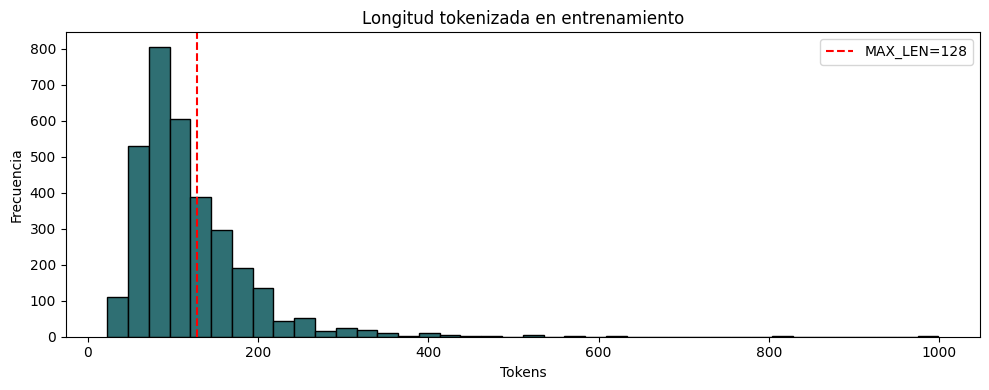

In [60]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

all_train_texts = np.concatenate([cat_data['X_train'], sub_data['X_train']])
token_lengths = pd.Series([
    len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
    for text in all_train_texts
])
max_len_dynamic = int(np.percentile(token_lengths, CONFIG['MAX_LEN_PERCENTILE']))
max_len_dynamic = int(math.ceil(max(max_len_dynamic, 32) / 8) * 8)
MAX_LEN = min(CONFIG['MAX_LEN_CAP'], max_len_dynamic)

print(token_lengths.describe())
print(f'MAX_LEN seleccionado: {MAX_LEN}')

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=40, color='#2F6F73', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Longitud tokenizada en entrenamiento')
plt.xlabel('Tokens')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Dataset y DataLoaders (CRISP-DM · fase 4)

In [61]:
class ViolenciaDataset(Dataset):
    def __init__(self, textos, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(textos),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': self.labels[idx],
        }


def _perturbar(texto, prob, rng):
    """Borrado e intercambio aleatorio de palabras (EDA sin diccionario externo).

    No inventa contenido: sólo degrada ligeramente el texto para que el modelo no pueda
    apoyarse en la secuencia exacta. Con textos cortos no hace nada, para no destruirlos.
    """
    palabras = texto.split()
    if len(palabras) < 10:
        return texto
    salida = [w for w in palabras if rng.random() > prob]
    if len(salida) < 5:
        salida = list(palabras)
    for _ in range(max(1, int(len(salida) * prob * 0.5))):
        i = rng.randrange(len(salida) - 1)
        salida[i], salida[i + 1] = salida[i + 1], salida[i]
    return ' '.join(salida)


def aumentar_entrenamiento(X, y, nombre=''):
    """Añade copias perturbadas del conjunto de entrenamiento.

    Sólo afecta a los datos con los que se ajustan los pesos. La medición en train
    (train_eval_loader) se hace siempre sobre el conjunto ORIGINAL, para que la brecha
    train-validación siga siendo interpretable.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    if not CONFIG['AUGMENTAR_TRAIN']:
        return X, y
    rng = random.Random(CONFIG['SEED'])
    Xa, ya = list(X), list(y)
    for texto, etiqueta in zip(X, y):
        for _ in range(CONFIG['AUG_COPIAS']):
            Xa.append(_perturbar(str(texto), CONFIG['AUG_PROB'], rng))
            ya.append(etiqueta)
    print(f'  Aumentación {nombre}: {len(X):,} -> {len(Xa):,} ejemplos de entrenamiento')
    return np.asarray(Xa), np.asarray(ya)


def make_weighted_sampler(labels):
    counts = Counter(labels)
    weights = np.array([1.0 / counts[int(label)] for label in labels], dtype=np.float64)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


def make_loaders(data, nombre=''):
    # MAX_LEN se resuelve aquí y no una sola vez de forma global, para que
    # AJUSTES_SUBCATEGORIA pueda darle a subcategoría un contexto distinto al de
    # categoría. `max_len_dynamic` (percentil de longitud) es común a las dos tareas;
    # lo que cambia por tarea es el tope MAX_LEN_CAP.
    max_len = min(CONFIG['MAX_LEN_CAP'], max_len_dynamic)
    if max_len != MAX_LEN:
        print(f'  {nombre}: MAX_LEN={max_len} (global {MAX_LEN})')
    X_fit, y_fit = aumentar_entrenamiento(data['X_train'], data['y_train'], nombre)
    train_ds = ViolenciaDataset(X_fit, y_fit, tokenizer, max_len)
    # Medición: conjunto de entrenamiento ORIGINAL, sin aumentar ni re-muestrear.
    train_eval_ds = ViolenciaDataset(data['X_train'], data['y_train'], tokenizer, max_len)
    val_ds = ViolenciaDataset(data['X_val'], data['y_val'], tokenizer, max_len)
    test_ds = ViolenciaDataset(data['X_test'], data['y_test'], tokenizer, max_len)
    sampler = make_weighted_sampler(y_fit) if CONFIG['USE_WEIGHTED_SAMPLER'] else None
    # `train_eval_ds` es el MISMO conjunto de entrenamiento, pero sin re-muestreo y sin
    # barajar: sirve para medir el rendimiento en train de la misma forma que se mide en
    # validación. Sin esto, la curva de train sale del flujo del sampler (distribución
    # rebalanceada) y no es comparable con la de validación.
    return (
        DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=sampler is None, sampler=sampler,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
        DataLoader(val_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
        DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
        DataLoader(train_eval_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False,
                   num_workers=CONFIG['NUM_WORKERS'], pin_memory=DEVICE.type == 'cuda'),
    )

cat_train_loader, cat_val_loader, cat_test_loader, cat_train_eval_loader = make_loaders(cat_data, 'categoría')
with con_ajustes(AJUSTES_SUBCATEGORIA):
    sub_train_loader, sub_val_loader, sub_test_loader, sub_train_eval_loader = make_loaders(sub_data, 'subcategoría')
print(f'Categoría batches train/val/test: {len(cat_train_loader)}, {len(cat_val_loader)}, {len(cat_test_loader)}')
print(f'Subcategoría batches train/val/test: {len(sub_train_loader)}, {len(sub_val_loader)}, {len(sub_test_loader)}')
print(f'Loader de medición en train (sin re-muestreo): {len(cat_train_eval_loader)} y {len(sub_train_eval_loader)} batches')

  Aumentación categoría: 1,714 -> 8,570 ejemplos de entrenamiento
  subcategoría: MAX_LEN=160 (global 128)
  Aumentación subcategoría: 1,545 -> 7,725 ejemplos de entrenamiento
Categoría batches train/val/test: 536, 23, 23
Subcategoría batches train/val/test: 483, 21, 21
Loader de medición en train (sin re-muestreo): 108 y 97 batches


## 12. Modelo Transformer single-label (CRISP-DM · fase 4)

In [62]:
class TransformerClasificador(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.30, extra_features=0,
                 head_hidden=None):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden = self.transformer.config.hidden_size
        # Ancho de la cabeza: cuantas menos unidades, menos sitio donde memorizar.
        head_hidden = head_hidden or CONFIG['HEAD_HIDDEN']
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden + extra_features, head_hidden)
        self.drop2 = nn.Dropout(dropout)
        self.out = nn.Linear(head_hidden, num_classes)

    def forward(self, input_ids, attention_mask, extra=None):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        if extra is not None:
            cls = torch.cat([cls, extra], dim=1)
        x = F.gelu(self.fc1(cls))
        x = self.drop2(x)
        return self.out(x)


def freeze_lower_layers(model, freeze_embeddings=True, freeze_layers=0):
    frozen = 0
    base = model.transformer
    if freeze_embeddings and hasattr(base, 'embeddings'):
        for p in base.embeddings.parameters():
            p.requires_grad = False
            frozen += p.numel()
    layers = getattr(getattr(base, 'encoder', None), 'layer', None)
    if layers is not None:
        for layer in layers[:freeze_layers]:
            for p in layer.parameters():
                p.requires_grad = False
                frozen += p.numel()
    # El pooler no se usa: forward() toma last_hidden_state[:, 0, :], no pooler_output.
    # Dejarlo entrenable inflaba el conteo de parámetros en 0.59M que nunca reciben
    # gradiente y sólo acumulaban weight decay.
    if getattr(base, 'pooler', None) is not None:
        for p in base.pooler.parameters():
            p.requires_grad = False
            frozen += p.numel()
    return frozen


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Re-sembrar antes de instanciar cada modelo: la inicialización de las cabezas consume
# el estado del RNG, así que sin esto model_sub depende de si model_cat se creó antes.
set_seed(CONFIG['SEED'])
model_cat = TransformerClasificador(MODEL_NAME, len(cat_data['le'].classes_), CONFIG['DROPOUT']).to(DEVICE)
set_seed(CONFIG['SEED'])
with con_ajustes(AJUSTES_SUBCATEGORIA):
    extra_sub = len(cat_data['le'].classes_) if CONFIG['USE_HIERARCHY_FOR_SUBCATEGORY'] else 0
    model_sub = TransformerClasificador(MODEL_NAME, len(sub_data['le'].classes_), CONFIG['DROPOUT'], extra_features=extra_sub).to(DEVICE)
    frozen_sub = freeze_lower_layers(model_sub, CONFIG['FREEZE_EMBEDDINGS'], CONFIG['FREEZE_LOWER_LAYERS'])

frozen_cat = freeze_lower_layers(model_cat, CONFIG['FREEZE_EMBEDDINGS'], CONFIG['FREEZE_LOWER_LAYERS'])
for title, model, frozen in [('Categoría', model_cat, frozen_cat), ('Subcategoría', model_sub, frozen_sub)]:
    total, trainable = count_params(model)
    print(f'{title}: total={total:,} | entrenables={trainable:,} | congelados={frozen:,}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Categoría: total=109,900,421 | entrenables=7,137,413 | congelados=102,763,008
Subcategoría: total=109,901,391 | entrenables=7,138,383 | congelados=102,763,008


## 13. Pérdida, optimizador y entrenamiento (CRISP-DM · fase 4)

Dos ajustes técnicos respecto a la versión 1:

- `torch.cuda.amp.GradScaler` / `autocast` están obsoletos desde PyTorch 2.4 y emitían un
  `FutureWarning` en cada época. Se migran a `torch.amp.*`.
- El `GradScaler` se creaba **dentro** de `train_epoch`, así que se reiniciaba en cada época y
  perdía su factor de escala adaptado. Ahora se crea una sola vez por entrenamiento.

In [63]:
def make_criterion(labels, num_classes):
    weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=labels)
    weights = np.sqrt(weights)
    weights = weights / weights.mean()
    return nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE),
        label_smoothing=CONFIG['LABEL_SMOOTHING'],
    )

criterion_cat = make_criterion(cat_data['y_train'], len(cat_data['le'].classes_))
with con_ajustes(AJUSTES_SUBCATEGORIA):
    criterion_sub = make_criterion(sub_data['y_train'], len(sub_data['le'].classes_))


def crear_optimizer_scheduler(model, train_loader):
    """Optimizador con decaimiento de la tasa de aprendizaje por capa (LLRD).

    Con LLRD_DECAY < 1 la capa superior usa LR_TRANSFORMER y cada capa más abajo un factor
    menos. Las representaciones generales del preentrenamiento apenas se mueven, que es lo
    que se quiere con 1.700 ejemplos: ajustar lo específico sin desarmar lo general.
    Con LLRD_DECAY = 1.0 el comportamiento es el original (un solo lr para todo).
    """
    decay = CONFIG['LLRD_DECAY']
    base_lr = CONFIG['LR_TRANSFORMER']
    wd_t = CONFIG['WEIGHT_DECAY_TRANSFORMER']
    grupos = []

    capas = list(model.transformer.encoder.layer)
    n_capas = len(capas)
    for i, capa in enumerate(capas):
        params = [p for p in capa.parameters() if p.requires_grad]
        if params:
            grupos.append({'params': params,
                           'lr': base_lr * (decay ** (n_capas - 1 - i)),
                           'weight_decay': wd_t})
    # Embeddings y cualquier otro parámetro del transformer que siga descongelado.
    resto = [p for nombre, p in model.transformer.named_parameters()
             if p.requires_grad and not nombre.startswith('encoder.layer.')]
    if resto:
        grupos.append({'params': resto, 'lr': base_lr * (decay ** n_capas), 'weight_decay': wd_t})

    head_params = [p for name, p in model.named_parameters() if p.requires_grad and not name.startswith('transformer.')]
    grupos.append({'params': head_params, 'lr': CONFIG['LR_HEAD'], 'weight_decay': CONFIG['WEIGHT_DECAY_HEAD']})
    optimizer = torch.optim.AdamW(grupos)
    total_steps = max(1, CONFIG['EPOCHS'] * len(train_loader))
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(total_steps * 0.08)),
        num_training_steps=total_steps,
    )
    return optimizer, scheduler


def get_category_extra(model_cat_ref, input_ids, attention_mask):
    if model_cat_ref is None:
        return None
    model_cat_ref.eval()
    with torch.no_grad():
        return F.softmax(model_cat_ref(input_ids, attention_mask), dim=1)


def train_epoch(model, loader, optimizer, scheduler, criterion, scaler, model_cat_ref=None):
    model.train()
    total_loss = 0.0
    preds, labels_all = [], []
    use_amp = DEVICE.type == 'cuda'
    alpha_rdrop = CONFIG['RDROP_ALPHA']

    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            extra = get_category_extra(model_cat_ref, input_ids, attention_mask)
            logits = model(input_ids, attention_mask, extra=extra)
            if alpha_rdrop > 0:
                # R-Drop: segunda pasada con otra máscara de dropout. La penalización KL
                # obliga al modelo a dar la misma respuesta bajo perturbación interna, que
                # es precisamente lo que un modelo que memoriza no puede hacer.
                logits2 = model(input_ids, attention_mask, extra=extra)
                loss_clasificacion = 0.5 * (criterion(logits, labels) + criterion(logits2, labels))
                lp1 = F.log_softmax(logits, dim=-1)
                lp2 = F.log_softmax(logits2, dim=-1)
                kl = 0.5 * (F.kl_div(lp1, lp2, log_target=True, reduction='batchmean')
                            + F.kl_div(lp2, lp1, log_target=True, reduction='batchmean'))
                # El KL entra en el gradiente pero NO en la pérdida que se reporta: la
                # validación no lo tiene, y sumarlo hacía que la curva de train apareciera
                # por encima de la de validación comparando cosas distintas.
                loss = loss_clasificacion + alpha_rdrop * kl
            else:
                loss_clasificacion = criterion(logits, labels)
                loss = loss_clasificacion

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        # Se acumula sólo la parte de clasificación. El término KL de R-Drop entra en el
        # gradiente, pero no en la cifra que se reporta: `val_loss` no lo tiene y sumarlo
        # haría que las dos columnas midieran cosas distintas.
        total_loss += loss_clasificacion.item() * len(labels)
        preds.extend(logits.argmax(1).detach().cpu().numpy())
        labels_all.extend(labels.detach().cpu().numpy())

    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(labels_all, preds),
        'f1_macro': f1_score(labels_all, preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(labels_all, preds, average='weighted', zero_division=0),
    }


def evaluate_loader(model, loader, criterion, model_cat_ref=None):
    model.eval()
    total_loss = 0.0
    preds, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)
            extra = get_category_extra(model_cat_ref, input_ids, attention_mask)
            logits = model(input_ids, attention_mask, extra=extra)
            loss = criterion(logits, labels)
            probs = F.softmax(logits, dim=1)
            total_loss += loss.item() * len(labels)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            probs_all.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(labels_all, preds),
        'f1_macro': f1_score(labels_all, preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(labels_all, preds, average='weighted', zero_division=0),
        'preds': np.array(preds),
        'labels': np.array(labels_all),
        'probs': np.array(probs_all),
    }


def entrenar_modelo(model, train_loader, val_loader, criterion, title, model_cat_ref=None,
                    train_eval_loader=None):
    """Entrena con early stopping y restaura los mejores pesos.

    `train_eval_loader` es el conjunto de entrenamiento SIN re-muestrear, evaluado en modo
    eval. Es la única curva de train comparable con la de validación: la que sale del bucle
    (`tr_f1m`) se calcula sobre el flujo del WeightedRandomSampler y con dropout activo, así
    que mide una distribución distinta y exagera la brecha. Se registran las dos.
    """
    optimizer, scheduler = crear_optimizer_scheduler(model, train_loader)
    # Un solo GradScaler por entrenamiento: conserva el factor de escala entre épocas.
    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
    best_f1 = -1.0
    best_state = None
    patience_count = 0
    history = []

    print(f'\n=== Entrenando {title} ===')
    print(f'{"época":>5} | {"tr_loss":>8} | {"tr_f1m":>7} | {"trE_f1m":>7} | '
          f'{"val_loss":>8} | {"val_f1m":>7} | {"brecha":>7}')
    print('-' * 78)

    for epoch in range(1, CONFIG['EPOCHS'] + 1):
        train_metrics = train_epoch(model, train_loader, optimizer, scheduler, criterion, scaler, model_cat_ref)
        val_metrics = evaluate_loader(model, val_loader, criterion, model_cat_ref)
        row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()},
               **{f'val_{k}': v for k, v in val_metrics.items() if k not in ['preds', 'labels', 'probs']}}

        # Curva de train comparable con validación (mismo modo eval, misma distribución).
        if train_eval_loader is not None:
            te = evaluate_loader(model, train_eval_loader, criterion, model_cat_ref)
            row['train_eval_loss'] = te['loss']
            row['train_eval_f1_macro'] = te['f1_macro']
            row['brecha_f1_macro'] = te['f1_macro'] - val_metrics['f1_macro']
            te_txt = f'{te["f1_macro"]:7.4f}'
            br_txt = f'{row["brecha_f1_macro"]:7.4f}'
        else:
            te_txt, br_txt = '      -', '      -'
        history.append(row)
        print(f'{epoch:5d} | {train_metrics["loss"]:8.4f} | {train_metrics["f1_macro"]:7.4f} | '
              f'{te_txt} | {val_metrics["loss"]:8.4f} | {val_metrics["f1_macro"]:7.4f} | {br_txt}')

        if val_metrics['f1_macro'] > best_f1 + CONFIG['MIN_DELTA']:
            best_f1 = val_metrics['f1_macro']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= CONFIG['PATIENCE']:
                print(f'Early stopping en época {epoch}.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'Mejor F1 Macro validación {title}: {best_f1:.4f}')
    return pd.DataFrame(history)

## 14. Entrenar modelo de categoría (CRISP-DM · fase 4)

In [64]:
history_cat = entrenar_modelo(
    model_cat,
    cat_train_loader,
    cat_val_loader,
    criterion_cat,
    title='categoría',
    train_eval_loader=cat_train_eval_loader,
)


=== Entrenando categoría ===
época |  tr_loss |  tr_f1m | trE_f1m | val_loss | val_f1m |  brecha
------------------------------------------------------------------------------
    1 |   1.8959 |  0.1920 |  0.1544 |   1.8180 |  0.1545 | -0.0002
    2 |   1.8192 |  0.2110 |  0.1544 |   1.7860 |  0.1545 | -0.0002
    3 |   1.7376 |  0.3675 |  0.5862 |   1.6177 |  0.5703 |  0.0159
    4 |   1.6077 |  0.5869 |  0.8180 |   1.4770 |  0.7391 |  0.0789
    5 |   1.5197 |  0.6928 |  0.8558 |   1.4019 |  0.8305 |  0.0253
    6 |   1.4669 |  0.7541 |  0.8656 |   1.3561 |  0.8556 |  0.0100
    7 |   1.4315 |  0.7798 |  0.8738 |   1.3214 |  0.8749 | -0.0012
    8 |   1.3998 |  0.8145 |  0.8823 |   1.2936 |  0.8688 |  0.0135
    9 |   1.3802 |  0.8162 |  0.8894 |   1.2775 |  0.8701 |  0.0193
   10 |   1.3640 |  0.8348 |  0.8967 |   1.2700 |  0.8701 |  0.0266
   11 |   1.3522 |  0.8444 |  0.9010 |   1.2559 |  0.8736 |  0.0275
   12 |   1.3404 |  0.8423 |  0.9059 |   1.2491 |  0.8836 |  0.0223
   13 |

## 15. Entrenar modelo de subcategoría (CRISP-DM · fase 4)

In [65]:
with con_ajustes(AJUSTES_SUBCATEGORIA):
    sub_model_cat_ref = model_cat if CONFIG['USE_HIERARCHY_FOR_SUBCATEGORY'] else None
if sub_model_cat_ref is not None:
    for p in model_cat.parameters():
        p.requires_grad_(False)
    model_cat.eval()

with con_ajustes(AJUSTES_SUBCATEGORIA):
    history_sub = entrenar_modelo(
        model_sub,
        sub_train_loader,
        sub_val_loader,
        criterion_sub,
        title='subcategoría',
        model_cat_ref=sub_model_cat_ref,
        train_eval_loader=sub_train_eval_loader,
    )


=== Entrenando subcategoría ===
época |  tr_loss |  tr_f1m | trE_f1m | val_loss | val_f1m |  brecha
------------------------------------------------------------------------------
    1 |   2.9752 |  0.0538 |  0.0917 |   2.9218 |  0.0885 |  0.0031
    2 |   2.9131 |  0.0790 |  0.0697 |   2.8735 |  0.0682 |  0.0016
    3 |   2.8079 |  0.1683 |  0.3405 |   2.6837 |  0.3353 |  0.0052
    4 |   2.6372 |  0.3228 |  0.5668 |   2.4824 |  0.5141 |  0.0527
    5 |   2.4888 |  0.4248 |  0.6489 |   2.3369 |  0.5911 |  0.0578
    6 |   2.3946 |  0.5065 |  0.7017 |   2.2498 |  0.6201 |  0.0816
    7 |   2.3246 |  0.5586 |  0.7123 |   2.1789 |  0.6310 |  0.0812
    8 |   2.2699 |  0.5917 |  0.7326 |   2.1393 |  0.7018 |  0.0308
    9 |   2.2274 |  0.6265 |  0.7520 |   2.0873 |  0.7076 |  0.0444
   10 |   2.1901 |  0.6432 |  0.7567 |   2.0650 |  0.7323 |  0.0245
   11 |   2.1724 |  0.6517 |  0.7879 |   2.0461 |  0.7608 |  0.0271
   12 |   2.1392 |  0.6748 |  0.7980 |   2.0151 |  0.7747 |  0.0233
   1

## 16. Curvas de aprendizaje (CRISP-DM · fase 4)

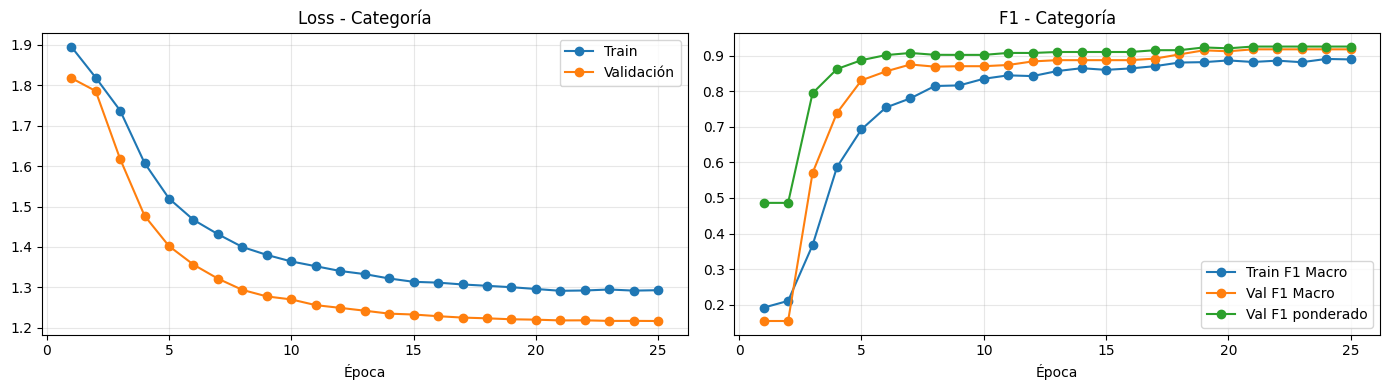

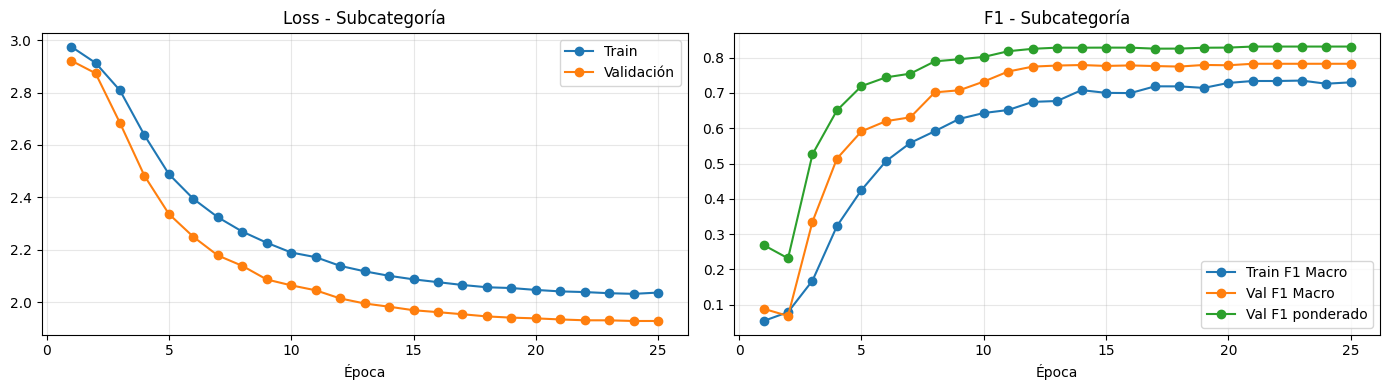

In [66]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train')
    axes[0].plot(history['epoch'], history['val_loss'], marker='o', label='Validación')
    axes[0].set_title(f'Loss - {title}')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['epoch'], history['train_f1_macro'], marker='o', label='Train F1 Macro')
    axes[1].plot(history['epoch'], history['val_f1_macro'], marker='o', label='Val F1 Macro')
    axes[1].plot(history['epoch'], history['val_f1_weighted'], marker='o', label='Val F1 ponderado')
    axes[1].set_title(f'F1 - {title}')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history_cat, 'Categoría')
plot_history(history_sub, 'Subcategoría')

## 17. Evaluación final en test (CRISP-DM · fase 5)

In [67]:
result_cat = evaluate_loader(model_cat, cat_test_loader, criterion_cat)
result_sub = evaluate_loader(model_sub, sub_test_loader, criterion_sub, model_cat_ref=sub_model_cat_ref)

print('=== RESULTADOS TEST - TRANSFORMER CATEGORÍA ===')
print({k: round(v, 4) for k, v in result_cat.items() if k in ['loss', 'accuracy', 'f1_macro', 'f1_weighted']})
print(classification_report(result_cat['labels'], result_cat['preds'], labels=np.arange(len(cat_data['le'].classes_)), target_names=cat_data['le'].classes_, zero_division=0))

print('=== RESULTADOS TEST - TRANSFORMER SUBCATEGORÍA ===')
print({k: round(v, 4) for k, v in result_sub.items() if k in ['loss', 'accuracy', 'f1_macro', 'f1_weighted']})
print(classification_report(result_sub['labels'], result_sub['preds'], labels=np.arange(len(sub_data['le'].classes_)), target_names=sub_data['le'].classes_, zero_division=0))

comparacion = pd.DataFrame([
    {'modelo': 'Baseline global categoría', **baseline_cat_test},
    {'modelo': 'Transformer categoría', **{k: result_cat[k] for k in ['accuracy', 'f1_macro', 'f1_weighted']}},
    {'modelo': 'Baseline global subcategoría', **baseline_sub_test},
    {'modelo': 'Baseline jerárquico subcategoría', **hier_sub_test},
    {'modelo': 'Transformer subcategoría', **{k: result_sub[k] for k in ['accuracy', 'f1_macro', 'f1_weighted']}},
])
display(comparacion)

objetivo = CONFIG['TARGET_MACRO_F1']
comparacion['cumple_objetivo_macro'] = comparacion['f1_macro'] >= objetivo
print(f'Objetivo macro-F1: >= {objetivo:.2f}')
display(comparacion.sort_values('f1_macro', ascending=False))


=== RESULTADOS TEST - TRANSFORMER CATEGORÍA ===
{'loss': 1.2537, 'accuracy': 0.9158, 'f1_macro': 0.8894, 'f1_weighted': 0.9161}
                                   precision    recall  f1-score   support

                 Acciones armadas       0.92      0.81      0.86        67
Ataques contra la población civil       0.96      0.94      0.95       231
           Desplazamiento forzado       0.88      1.00      0.93         7
Restricción al acceso humanitario       0.82      0.90      0.86        30
     Uso de artefactos explosivos       0.78      0.94      0.85        33

                         accuracy                           0.92       368
                        macro avg       0.87      0.92      0.89       368
                     weighted avg       0.92      0.92      0.92       368

=== RESULTADOS TEST - TRANSFORMER SUBCATEGORÍA ===
{'loss': 1.8303, 'accuracy': 0.8795, 'f1_macro': 0.8405, 'f1_weighted': 0.8796}
                                                     precision 

,modelo,accuracy,f1_macro,f1_weighted
0,Baseline global categoría,0.932065,0.911926,0.932738
1,Transformer categoría,0.915761,0.889365,0.916110
2,Baseline global subcategoría,0.864458,0.831712,0.865425
3,Baseline jerárquico subcategoría,0.861446,0.826463,0.861057
4,Transformer subcategoría,0.879518,0.840484,0.879623


Objetivo macro-F1: >= 0.85


,modelo,accuracy,f1_macro,f1_weighted,cumple_objetivo_macro
0,Baseline global categoría,0.932065,0.911926,0.932738,True
1,Transformer categoría,0.915761,0.889365,0.916110,True
4,Transformer subcategoría,0.879518,0.840484,0.879623,False
2,Baseline global subcategoría,0.864458,0.831712,0.865425,False
3,Baseline jerárquico subcategoría,0.861446,0.826463,0.861057,False


## 18. Matrices de confusión (CRISP-DM · fase 5)

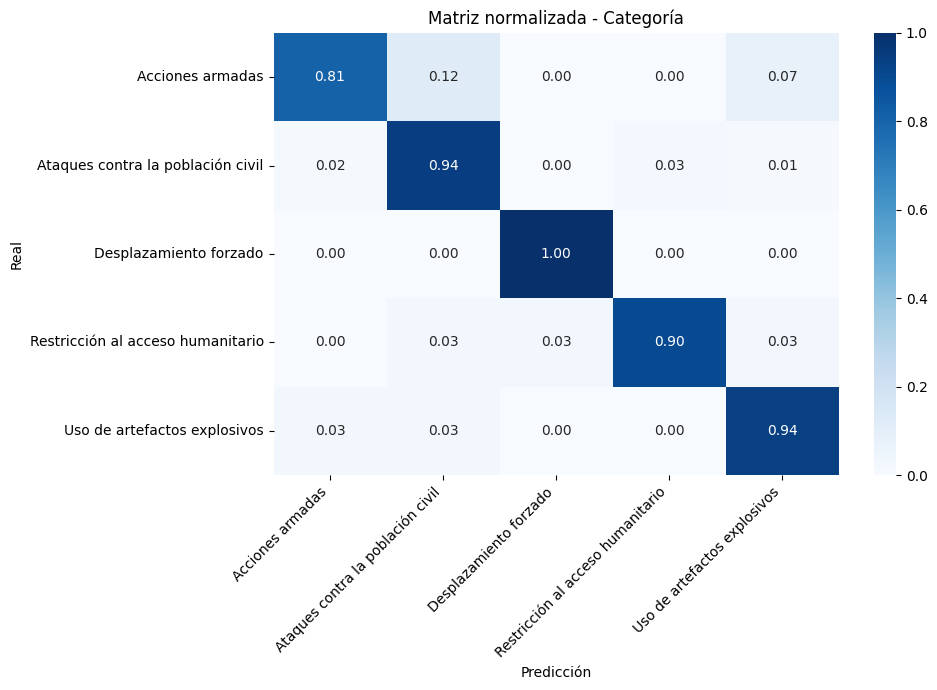

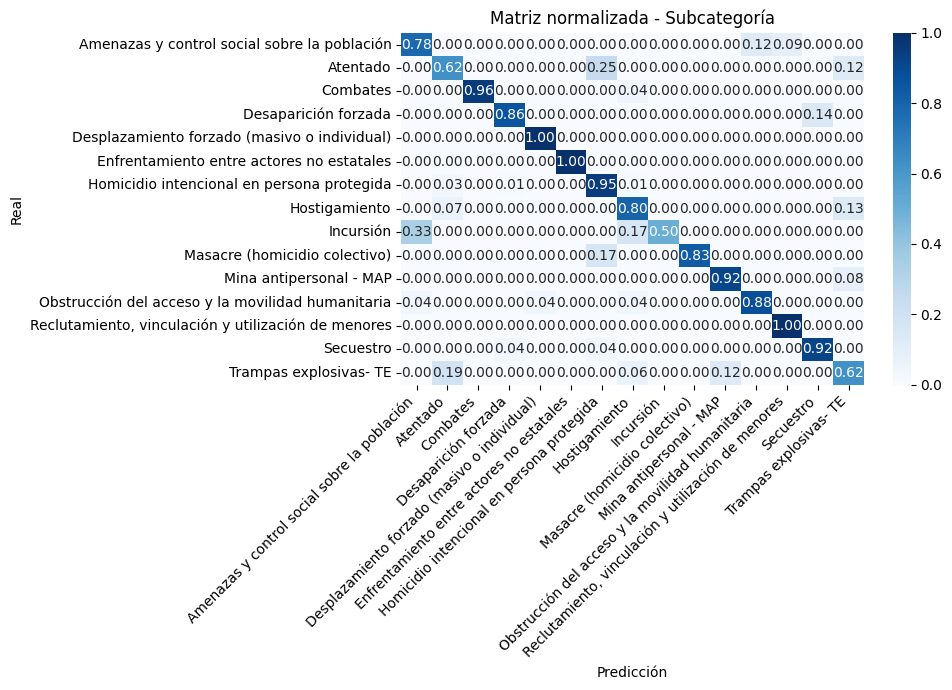

In [68]:
def plot_confusion(y_true, y_pred, labels, title, max_annot=35):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True), out=np.zeros_like(cm, dtype=float), where=cm.sum(axis=1, keepdims=True) != 0)
    figsize = (min(24, max(10, len(labels) * 0.55)), min(20, max(7, len(labels) * 0.45)))
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm_norm,
        annot=len(labels) <= max_annot,
        fmt='.2f',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion(result_cat['labels'], result_cat['preds'], cat_data['le'].classes_, 'Matriz normalizada - Categoría')
plot_confusion(result_sub['labels'], result_sub['preds'], sub_data['le'].classes_, 'Matriz normalizada - Subcategoría')

## 19. Análisis de errores (CRISP-DM · fase 5)

In [69]:
def error_examples(data, result, le, n=20):
    rows = []
    for text, real, pred, probs in zip(data['X_test'], result['labels'], result['preds'], result['probs']):
        if real == pred:
            continue
        rows.append({
            'texto': text[:500],
            'real': le.classes_[real],
            'predicción': le.classes_[pred],
            'confianza_predicción': float(probs[pred]),
            'confianza_real': float(probs[real]),
        })
    return pd.DataFrame(rows).sort_values('confianza_predicción', ascending=False).head(n)

print('Errores de mayor confianza - categoría')
display(error_examples(cat_data, result_cat, cat_data['le'], n=15))
print('Errores de mayor confianza - subcategoría')
display(error_examples(sub_data, result_sub, sub_data['le'], n=15))

Errores de mayor confianza - categoría


,texto,real,predicción,confianza_predicción,confianza_real
10,Restricciones a la movilidad contra misión hum...,Ataques contra la población civil,Restricción al acceso humanitario,0.919379,0.002444
4,Desplazamiento maisvo veredas limones y zabale...,Restricción al acceso humanitario,Desplazamiento forzado,0.878683,0.056561
14,Hombre fallece tras pisar una mina Antipersona...,Ataques contra la población civil,Uso de artefactos explosivos,0.822182,0.025404
13,Disidencias de las FARC plantan nuevamente car...,Acciones armadas,Uso de artefactos explosivos,0.816831,0.048634
12,Ataque con explosivos en el Portico || .Norte ...,Acciones armadas,Uso de artefactos explosivos,0.700969,0.106036
21,Evento a Misión en Teorama || .Norte De Santan...,Ataques contra la población civil,Restricción al acceso humanitario,0.698501,0.038253
6,Disidencias lanzaron drones con explosivos cer...,Acciones armadas,Uso de artefactos explosivos,0.564488,0.195297
16,"Ataque contra la fuerza publica, vía entre El ...",Acciones armadas,Uso de artefactos explosivos,0.545484,0.153683
23,Disidencias de las Farc iniciarían una guerra ...,Ataques contra la población civil,Acciones armadas,0.512510,0.110464
0,Secuestro de personal médico || Hombres armado...,Restricción al acceso humanitario,Ataques contra la población civil,0.493192,0.123815


Errores de mayor confianza - subcategoría


,texto,real,predicción,confianza_predicción,confianza_real
0,Desplazamiento forzado masivo y cancelación de...,Obstrucción del acceso y la movilidad humanitaria,Desplazamiento forzado (masivo o individual),0.608154,0.098225
28,Menores en riesgo por reclutamiento forzado en...,Amenazas y control social sobre la población,"Reclutamiento, vinculación y utilización de me...",0.577381,0.054797
13,Restricciones a la movilidad contra misión hum...,Amenazas y control social sobre la población,Obstrucción del acceso y la movilidad humanitaria,0.449203,0.063292
36,Nuevo caso de joven reportado cómo desaparecid...,Secuestro,Desaparición forzada,0.447977,0.175395
12,Intento de reclutamiento en municipio de Meset...,Amenazas y control social sobre la población,"Reclutamiento, vinculación y utilización de me...",0.436064,0.084001
15,Dos soldados resultaron heridos tras caer en c...,Trampas explosivas- TE,Mina antipersonal - MAP,0.392165,0.152386
19,Amenaza de reclutamiento a un menor en Carurú ...,Amenazas y control social sobre la población,"Reclutamiento, vinculación y utilización de me...",0.370162,0.171797
26,Individuos lanzan panfletos amenazantes || .No...,Incursión,Amenazas y control social sobre la población,0.365846,0.103076
30,Se presenta nuevo accidente MAP en zona rural ...,Trampas explosivas- TE,Mina antipersonal - MAP,0.364649,0.145183
22,Asesinan a un hombre y dejan panfleto del EGC ...,Atentado,Homicidio intencional en persona protegida,0.334966,0.059988


In [70]:
# Utilidad compartida por las secciones 20, 21 y 23: predice sobre una lista de textos.

@torch.no_grad()
def predecir_lote(textos, batch_size=32, aplicar_mascara=False):
    """Devuelve (probs_categoria, probs_subcategoria) para una lista de textos.

    Si `aplicar_mascara` es True, las subcategorías incompatibles con la categoría predicha
    reciben probabilidad 0 y el resto se renormaliza (corrección D1 en inferencia).
    """
    model_cat.eval()
    model_sub.eval()
    textos = [normalize_text(t) for t in textos]
    probs_cat, probs_sub = [], []

    for start in range(0, len(textos), batch_size):
        lote = textos[start:start + batch_size]
        enc = tokenizer(lote, max_length=MAX_LEN, padding='max_length',
                        truncation=True, return_tensors='pt')
        input_ids = enc['input_ids'].to(DEVICE)
        attention_mask = enc['attention_mask'].to(DEVICE)

        pc = F.softmax(model_cat(input_ids, attention_mask), dim=1)
        extra = pc if CONFIG['USE_HIERARCHY_FOR_SUBCATEGORY'] else None
        ps = F.softmax(model_sub(input_ids, attention_mask, extra=extra), dim=1)

        pc_np = pc.cpu().numpy()
        ps_np = ps.cpu().numpy()

        if aplicar_mascara and CONFIG['MASK_SUBCATEGORY_BY_CATEGORY']:
            for fila in range(len(lote)):
                permitidas = SUBCATEGORY_MASK[int(pc_np[fila].argmax())]
                if permitidas.any():
                    ps_np[fila] = np.where(permitidas, ps_np[fila], 0.0)
                    total = ps_np[fila].sum()
                    ps_np[fila] = ps_np[fila] / total if total > 0 else permitidas / permitidas.sum()

        probs_cat.append(pc_np)
        probs_sub.append(ps_np)

    return np.vstack(probs_cat), np.vstack(probs_sub)


print('predecir_lote listo.')

predecir_lote listo.


## 20. Robustez léxica: ¿aprende el concepto o memoriza la palabra? (CRISP-DM · fase 5)

Esta sección responde a un riesgo específico detectado al auditar `Desplazamiento forzado`.

El campo `texto_evento` concatena el **título** del reporte con su descripción, y los títulos
tienden a nombrar la categoría de forma literal: *«Desplazamiento masivo en la vereda La Corona»*.
Si el 100 % de los ejemplos de una clase contiene la palabra de su propia etiqueta, un macro-F1 alto
puede estar midiendo detección de palabra clave y no comprensión del evento.

La prueba tiene dos partes:

1. **Solapamiento léxico.** Para cada clase, qué proporción de sus eventos contiene el término
   característico de esa clase. En la versión 1: `Desplazamiento forzado` 100 %, frente a 48–78 %
   en las demás clases; es la única clase con solapamiento perfecto.

2. **Ablación.** Se reemplaza ese término por un sinónimo neutro en el conjunto de test y se mide
   cuánta exactitud sobrevive. El modelo v1 conservaba la clase en sólo **3 de 7** eventos de
   desplazamiento: al quitar la palabra, tres eventos migraban a la categoría de la *causa*
   (`Acciones armadas`, `Ataques contra la población civil`) y uno a `Restricción al acceso
   humanitario`.

La caída por ablación es un número que conviene reportar junto al F1: un modelo que sólo pierde unos
pocos puntos está usando el contexto; uno que se desploma está leyendo el título.

=== Solapamiento léxico por clase de categoría ===
Proporción de eventos cuyo texto contiene el término característico de su propia etiqueta.


,clase,eventos,contienen_su_termino,solapamiento_lexico
0,Desplazamiento forzado,52,52,1.000000
2,Uso de artefactos explosivos,219,170,0.776256
1,Acciones armadas,443,303,0.683973
4,Ataques contra la población civil,1539,794,0.515919
3,Restricción al acceso humanitario,196,95,0.484694


Clases con solapamiento >= 95 % (candidatas a memorización de palabra clave):


,clase,eventos,solapamiento_lexico
0,Desplazamiento forzado,52,1.0



=== Prueba de ablación léxica sobre el test de categoría ===
Exactitud con el texto original : 0.9158
Exactitud sin el término clave  : 0.8587
Caída por ablación              : 0.0571


,clase,n_test,acierto_original,acierto_ablado,caida
2,Desplazamiento forzado,7,1.000000,0.714286,0.285714
4,Uso de artefactos explosivos,33,0.939394,0.757576,0.181818
0,Acciones armadas,67,0.805970,0.701493,0.104478
3,Restricción al acceso humanitario,30,0.900000,0.800000,0.100000
1,Ataques contra la población civil,231,0.943723,0.930736,0.012987


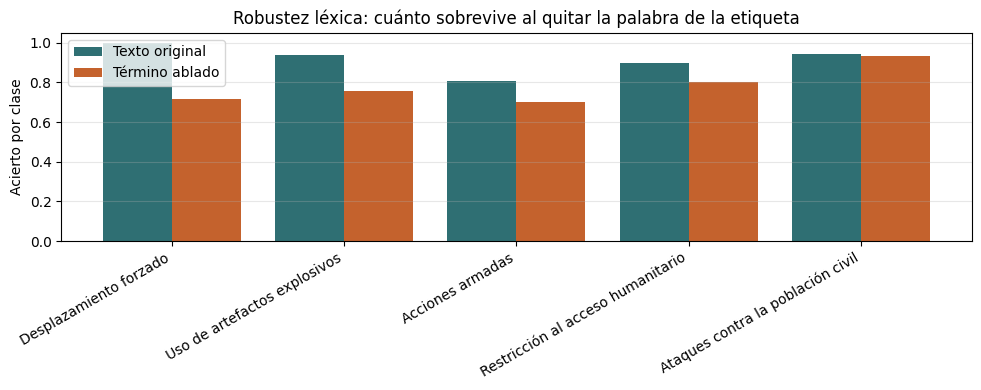

In [71]:
# Términos característicos por clase. La regex se aplica sobre el texto en minúsculas.
TERMINOS_POR_CLASE = {
    'Desplazamiento forzado': r'desplaz\w*',
    'Acciones armadas': r'combate\w*|hostigamiento\w*|enfrentamient\w*',
    'Uso de artefactos explosivos': r'explosiv\w*|mina\s+antipersonal|artefacto\w*',
    'Restricción al acceso humanitario': r'confinamiento\w*|restricc\w*|acceso\s+humanitario',
    'Ataques contra la población civil': r'homicidio\w*|amenaz\w*|secuestr\w*|atentado\w*|reclutamiento\w*',
}
REEMPLAZO_NEUTRO = 'evento'


def medir_solapamiento_lexico(df, label_col='label'):
    filas = []
    for clase, patron in TERMINOS_POR_CLASE.items():
        grupo = df[df[label_col] == clase]
        if not len(grupo):
            continue
        con_termino = grupo['texto_evento'].str.contains(patron, case=False, regex=True, na=False).sum()
        filas.append({
            'clase': clase,
            'eventos': len(grupo),
            'contienen_su_termino': int(con_termino),
            'solapamiento_lexico': con_termino / len(grupo),
        })
    return pd.DataFrame(filas).sort_values('solapamiento_lexico', ascending=False)

solapamiento = medir_solapamiento_lexico(cat_df)
print('=== Solapamiento léxico por clase de categoría ===')
print('Proporción de eventos cuyo texto contiene el término característico de su propia etiqueta.')
display(solapamiento)

riesgo = solapamiento[solapamiento['solapamiento_lexico'] >= 0.95]
if len(riesgo):
    print('Clases con solapamiento >= 95 % (candidatas a memorización de palabra clave):')
    display(riesgo[['clase', 'eventos', 'solapamiento_lexico']])


def ablacionar(texto, patron, reemplazo=REEMPLAZO_NEUTRO):
    return re.sub(patron, reemplazo, texto, flags=re.IGNORECASE)


def prueba_de_ablacion(data, le_cat):
    """Compara la exactitud del modelo de categoría antes y después de borrar el término."""
    test_df = data['test_df']
    textos_orig = list(test_df['texto_evento'].values)
    textos_abl = [
        ablacionar(t, TERMINOS_POR_CLASE.get(y, r'(?!x)x'))
        for t, y in zip(textos_orig, test_df['label'].values)
    ]

    pc_orig, _ = predecir_lote(textos_orig)
    pc_abl, _ = predecir_lote(textos_abl)
    pred_orig = le_cat.classes_[pc_orig.argmax(axis=1)]
    pred_abl = le_cat.classes_[pc_abl.argmax(axis=1)]
    y_true = test_df['label'].values

    filas = []
    for clase in le_cat.classes_:
        mask = y_true == clase
        if not mask.any():
            continue
        acc_o = float((pred_orig[mask] == clase).mean())
        acc_a = float((pred_abl[mask] == clase).mean())
        filas.append({
            'clase': clase,
            'n_test': int(mask.sum()),
            'acierto_original': acc_o,
            'acierto_ablado': acc_a,
            'caida': acc_o - acc_a,
        })
    detalle = pd.DataFrame(filas).sort_values('caida', ascending=False)

    global_o = float((pred_orig == y_true).mean())
    global_a = float((pred_abl == y_true).mean())
    return detalle, global_o, global_a

ablacion_detalle, acc_original, acc_ablado = prueba_de_ablacion(cat_data, cat_data['le'])

print('\n=== Prueba de ablación léxica sobre el test de categoría ===')
print(f'Exactitud con el texto original : {acc_original:.4f}')
print(f'Exactitud sin el término clave  : {acc_ablado:.4f}')
print(f'Caída por ablación              : {acc_original - acc_ablado:.4f}')
display(ablacion_detalle)

plt.figure(figsize=(10, 4))
x = np.arange(len(ablacion_detalle))
plt.bar(x - 0.2, ablacion_detalle['acierto_original'], width=0.4, label='Texto original', color='#2F6F73')
plt.bar(x + 0.2, ablacion_detalle['acierto_ablado'], width=0.4, label='Término ablado', color='#C4622D')
plt.xticks(x, ablacion_detalle['clase'], rotation=30, ha='right')
plt.ylabel('Acierto por clase')
plt.title('Robustez léxica: cuánto sobrevive al quitar la palabra de la etiqueta')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

robustez_payload = {
    'solapamiento_lexico': solapamiento.set_index('clase')['solapamiento_lexico'].to_dict(),
    'accuracy_original': acc_original,
    'accuracy_ablado': acc_ablado,
    'caida_por_ablacion': acc_original - acc_ablado,
    'caida_por_clase': ablacion_detalle.set_index('clase')['caida'].to_dict(),
}

## 21. Coherencia jerárquica de la cascada (CRISP-DM · fase 5)

Métrica que la versión 1 no tenía y que expone directamente el defecto **D1**: la proporción de
predicciones cuya subcategoría **no pertenece** a la categoría predicha.

En la versión 1 esta métrica era del 100 % para `Desplazamiento forzado` y `Restricción al acceso
humanitario`, porque ninguna de sus subcategorías existía en el espacio de etiquetas del modelo. No
era un error de aprendizaje: era una imposibilidad estructural que el pipeline nunca comprobó.

Se reporta con y sin la máscara jerárquica, para cuantificar cuánto aporta la corrección.

In [72]:
def evaluar_coherencia(data, aplicar_mascara):
    textos = list(data['test_df']['texto_evento'].values)
    pc, ps = predecir_lote(textos, aplicar_mascara=aplicar_mascara)
    cat_pred = cat_data['le'].classes_[pc.argmax(axis=1)]
    sub_pred = sub_data['le'].classes_[ps.argmax(axis=1)]

    coherente = np.array([
        s in CATEGORY_TO_SUBCATEGORIES.get(str(c), [])
        for c, s in zip(cat_pred, sub_pred)
    ])
    acierto_sub = sub_pred == data['test_df']['label'].values
    return {
        'coherencia': float(coherente.mean()),
        'incoherentes': int((~coherente).sum()),
        'accuracy_subcategoria': float(acierto_sub.mean()),
        'f1_macro_subcategoria': float(f1_score(
            data['test_df']['label'].values, sub_pred, average='macro', zero_division=0)),
        'cat_pred': cat_pred,
        'sub_pred': sub_pred,
        'coherente': coherente,
    }

sin_mascara = evaluar_coherencia(sub_data, aplicar_mascara=False)
con_mascara = evaluar_coherencia(sub_data, aplicar_mascara=True)

comparacion_jerarquia = pd.DataFrame([
    {'variante': 'cascada sin máscara', **{k: sin_mascara[k] for k in
     ['coherencia', 'incoherentes', 'accuracy_subcategoria', 'f1_macro_subcategoria']}},
    {'variante': 'cascada con máscara jerárquica', **{k: con_mascara[k] for k in
     ['coherencia', 'incoherentes', 'accuracy_subcategoria', 'f1_macro_subcategoria']}},
])
print('=== Coherencia jerárquica en el test de subcategoría ===')
display(comparacion_jerarquia)

print('\nCoherencia por categoría predicha (sin máscara):')
detalle_coh = pd.DataFrame({
    'categoria_predicha': sin_mascara['cat_pred'],
    'coherente': sin_mascara['coherente'],
}).groupby('categoria_predicha')['coherente'].agg(['count', 'mean'])
detalle_coh.columns = ['predicciones', 'coherencia']
display(detalle_coh.sort_values('coherencia'))

if sin_mascara['incoherentes']:
    print('\nEjemplos de pares incoherentes (categoría -> subcategoría imposible):')
    idx = np.where(~sin_mascara['coherente'])[0][:10]
    display(pd.DataFrame({
        'categoria_predicha': sin_mascara['cat_pred'][idx],
        'subcategoria_predicha': sin_mascara['sub_pred'][idx],
        'texto': [sub_data['test_df']['texto_evento'].values[i][:110] for i in idx],
    }))
else:
    print('\nNo hay pares incoherentes: la cobertura jerárquica de la sección 8 los eliminó de raíz.')

coherencia_payload = {
    'coherencia_sin_mascara': sin_mascara['coherencia'],
    'coherencia_con_mascara': con_mascara['coherencia'],
    'accuracy_sub_sin_mascara': sin_mascara['accuracy_subcategoria'],
    'accuracy_sub_con_mascara': con_mascara['accuracy_subcategoria'],
    'f1_macro_sub_sin_mascara': sin_mascara['f1_macro_subcategoria'],
    'f1_macro_sub_con_mascara': con_mascara['f1_macro_subcategoria'],
}

=== Coherencia jerárquica en el test de subcategoría ===


,variante,coherencia,incoherentes,accuracy_subcategoria,f1_macro_subcategoria
0,cascada sin máscara,0.957831,14,0.879518,0.838098
1,cascada con máscara jerárquica,1.000000,0,0.894578,0.855937



Coherencia por categoría predicha (sin máscara):


,predicciones,coherencia
categoria_predicha,,
Uso de artefactos explosivos,32,0.812500
Restricción al acceso humanitario,28,0.892857
Acciones armadas,54,0.962963
Ataques contra la población civil,210,0.985714
Desplazamiento forzado,8,1.000000



Ejemplos de pares incoherentes (categoría -> subcategoría imposible):


,categoria_predicha,subcategoria_predicha,texto
0,Restricción al acceso humanitario,Desplazamiento forzado (masivo o individual),Desplazamiento forzado masivo y cancelación de...
1,Restricción al acceso humanitario,Amenazas y control social sobre la población,Citación a reuniones por parte de un Grupo Arm...
2,Acciones armadas,Trampas explosivas- TE,Policia derriba dron de las disidencias en Pol...
3,Restricción al acceso humanitario,Trampas explosivas- TE,Grupo armado robó camioneta de la ESE Tierrade...
4,Uso de artefactos explosivos,Atentado,Ataque con explosivos a Camión en la Ye de Ast...
5,Ataques contra la población civil,Obstrucción del acceso y la movilidad humanitaria,Alerta Temprana de la Defensoría del Pueblo No...
6,Uso de artefactos explosivos,Hostigamiento,Nuevo ataque al Ejército con drones en zona ru...
7,Uso de artefactos explosivos,Atentado,Dos soldados heridos en ataque con explosivos ...
8,Uso de artefactos explosivos,Atentado,Empleados de la Continental Gold fueron atacad...
9,Acciones armadas,Trampas explosivas- TE,Lanzan granada en ias instalaciones del Gaula ...


## 22. Guardado de artefactos (CRISP-DM · fase 6)

Además de los pesos y los codificadores, el JSON de despliegue ahora incluye el contrato jerárquico
que el servicio de inferencia necesita para no repetir el defecto D1:

- `category_to_subcategories`: qué subcategorías son alcanzables desde cada categoría.
- `subcategory_mask`: la misma relación como matriz booleana, lista para enmascarar logits.
- `subcategory_merge_map`: qué etiquetas originales se fusionaron, para poder revertir la
  trazabilidad hacia la taxonomía de la fuente.
- `robustez_lexica` y `coherencia_jerarquica`: las métricas de las secciones 20 y 21.

El backend debe leer `category_to_subcategories` y **abstenerse** de dar subcategoría cuando la
categoría predicha no tenga ninguna, en lugar de devolver el `argmax` global.

In [77]:
artifact_dir = Path(CONFIG['ARTIFACT_DIR'])
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f'Usando ARTIFACT_DIR = {artifact_dir.resolve()}')

torch.save(model_cat.state_dict(), artifact_dir / 'model_categoria.pt')
torch.save(model_sub.state_dict(), artifact_dir / 'model_subcategoria.pt')
tokenizer.save_pretrained(artifact_dir / 'tokenizer')
dump(cat_data['le'], artifact_dir / 'label_encoder_categoria.joblib')
dump(sub_data['le'], artifact_dir / 'label_encoder_subcategoria.joblib')
dump(baseline_cat, artifact_dir / 'baseline_categoria.joblib')
dump(baseline_sub, artifact_dir / 'baseline_subcategoria.joblib')
dump(hier_sub_global, artifact_dir / 'baseline_subcategoria_global_para_router.joblib')
dump(hier_sub_routers, artifact_dir / 'baseline_subcategoria_jerarquico.joblib')
dump(hier_sub_category_router, artifact_dir / 'baseline_router_categoria.joblib')

def _config_de_tarea(overrides=None):
    """Los parámetros que el servicio de inferencia necesita para RECONSTRUIR el modelo.

    Desde que categoría y subcategoría pueden entrenarse con perfiles distintos, estos tres
    valores dejaron de ser comunes. El servicio construye la cabeza con HEAD_HIDDEN y
    tokeniza con MAX_LEN: si los lee del bloque global, carga la subcategoría con la
    configuración de categoría — la cabeza falla por forma y el contexto queda truncado.
    """
    with con_ajustes(overrides or {}):
        return {
            'MODEL_NAME': MODEL_NAME,
            'MAX_LEN': int(min(CONFIG['MAX_LEN_CAP'], max_len_dynamic)),
            'HEAD_HIDDEN': int(CONFIG['HEAD_HIDDEN']),
            'DROPOUT': float(CONFIG['DROPOUT']),
        }


payload = {
    'config': {**{k: v for k, v in CONFIG.items() if k != 'SUBCATEGORY_MERGE_MAP'},
               'MODEL_NAME': MODEL_NAME, 'MAX_LEN': int(MAX_LEN)},
    'config_categoria': _config_de_tarea(),
    'config_subcategoria': _config_de_tarea(AJUSTES_SUBCATEGORIA),
    'n_events_total': int(len(events_df)),
    'n_category_trainable': int(len(cat_df)),
    'n_subcategory_trainable': int(len(sub_df)),
    'category_coverage_single_label': float(cat_coverage),
    'subcategory_coverage_single_label': float(sub_coverage),
    'n_category_excluded': int(len(cat_ambiguous)),
    'n_subcategory_excluded': int(len(sub_ambiguous)),
    'category_classes': cat_data['le'].classes_.tolist(),
    'subcategory_classes': sub_data['le'].classes_.tolist(),
    'category_removed_classes': {str(k): int(v) for k, v in cat_removed.items()},
    'subcategory_removed_classes': {str(k): int(v) for k, v in sub_removed.items()},
    # --- contrato jerárquico para el servicio de inferencia (corrección D1) ---
    'category_to_subcategories': CATEGORY_TO_SUBCATEGORIES,
    'subcategory_mask': SUBCATEGORY_MASK.astype(int).tolist(),
    'subcategory_merge_map': CONFIG['SUBCATEGORY_MERGE_MAP'],
    'mask_subcategory_by_category': bool(CONFIG['MASK_SUBCATEGORY_BY_CATEGORY']),
    # --- métricas ---
    'baseline_category_test': {k: float(v) for k, v in baseline_cat_test.items()},
    'baseline_subcategory_test': {k: float(v) for k, v in baseline_sub_test.items()},
    'hierarchical_baseline_subcategory_test': {k: float(v) for k, v in hier_sub_test.items()},
    'transformer_category_test': {k: float(result_cat[k]) for k in ['accuracy', 'f1_macro', 'f1_weighted']},
    'transformer_subcategory_test': {k: float(result_sub[k]) for k in ['accuracy', 'f1_macro', 'f1_weighted']},
    'robustez_lexica': robustez_payload,
    'coherencia_jerarquica': coherencia_payload,
}
with open(artifact_dir / 'metrics_config_singlelabel.json', 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

saved_files = sorted([p.name for p in artifact_dir.iterdir()])
print(f'Artefactos guardados en: {artifact_dir.resolve()}')
print('Archivos generados:', saved_files)
print('\nContrato jerárquico exportado:')
display(pd.DataFrame([
    {'categoria': c, 'subcategorias_alcanzables': len(s)}
    for c, s in CATEGORY_TO_SUBCATEGORIES.items()
]))

Usando ARTIFACT_DIR = /content/drive/MyDrive/violencia_classifier_artifacts
Artefactos guardados en: /content/drive/MyDrive/violencia_classifier_artifacts
Archivos generados: ['baseline_categoria.joblib', 'baseline_router_categoria.joblib', 'baseline_subcategoria.joblib', 'baseline_subcategoria_global_para_router.joblib', 'baseline_subcategoria_jerarquico.joblib', 'label_encoder_categoria.joblib', 'label_encoder_subcategoria.joblib', 'metrics_config_singlelabel.json', 'model_categoria.pt', 'model_subcategoria.pt', 'tokenizer']

Contrato jerárquico exportado:


,categoria,subcategorias_alcanzables
0,Acciones armadas,4
1,Ataques contra la población civil,7
2,Desplazamiento forzado,1
3,Restricción al acceso humanitario,1
4,Uso de artefactos explosivos,2


In [74]:
import json
import os

# Definir la ruta dentro de la misma carpeta de artefactos
artifact_dir = "/content/drive/MyDrive/violencia_classifier_artifacts"
contract_path = os.path.join(artifact_dir, "hierarchical_contract.json")

# Definición del contrato jerárquico
hierarchical_contract = {
    "version": "1.0",
    "artifacts": {
        "tokenizer": "tokenizer",
        "category_model": "model_categoria.pt",
        "subcategory_model": "model_subcategoria.pt",
        "label_encoder_category": "label_encoder_categoria.joblib",
        "label_encoder_subcategory": "label_encoder_subcategoria.joblib",
        "router": "baseline_router_categoria.joblib",
    },
    "hierarchy": {
        "Violencia Física": [
            "Agresión con arma",
            "Golpes",
            "Sujeción/Inmovilización",
        ],
        "Violencia Psicológica": [
            "Amenazas",
            "Intimidación",
            "Insultos/Humillaciones",
        ],
        "Violencia Verbal": ["Acoso verbal", "Lenguaje de odio"],
    },
}

# Guardar el contrato en Drive
with open(contract_path, "w", encoding="utf-8") as f:
    json.dump(hierarchical_contract, f, ensure_ascii=False, indent=4)

print(f"Contrato jerárquico guardado con éxito en: {contract_path}")

Contrato jerárquico guardado con éxito en: /content/drive/MyDrive/violencia_classifier_artifacts/hierarchical_contract.json


## 22.b Descarga de artefactos al PC

El backend lee los artefactos desde `./ml-artifacts/violencia_classifier_artifacts`
(configurable con `SENDA_BETO_ARTIFACT_DIR`). Esta celda los baja por el navegador para no
tener que pasar por Drive a mano.


In [75]:
# --- Descarga de los artefactos al PC ---------------------------------------------------
# Se baja en tres piezas a propósito. Los dos .pt pesan ~440 MB cada uno y la descarga por
# navegador de Colab falla con frecuencia en archivos grandes; separándolos, un fallo obliga
# a reintentar sólo esa pieza y no las once.
#
# Destino en tu PC: descomprimir el zip dentro de
#   Backend/ml-artifacts/violencia_classifier_artifacts/
# y dejar los dos .pt en esa misma carpeta, al lado de metrics_config_singlelabel.json.

DESCARGAR_AL_PC = True

if DESCARGAR_AL_PC:
    import zipfile
    from pathlib import Path

    try:
        from google.colab import files as colab_files
    except ImportError:
        colab_files = None

    origen = Path(CONFIG['ARTIFACT_DIR'])

    if colab_files is None:
        print('No estás en Colab: no hay descarga por navegador.')
        print(f'Copia manualmente el contenido de {origen}')
    else:
        # Todo menos los .pt. Incluye los baselines: el backend no los usa, pero hacen falta
        # para reproducir la comparación contra TF-IDF fuera de Colab.
        paquete = Path('/content/artefactos_violencia.zip')
        with zipfile.ZipFile(paquete, 'w', zipfile.ZIP_DEFLATED) as z:
            for ruta in sorted(origen.rglob('*')):
                if ruta.is_file() and ruta.suffix != '.pt':
                    z.write(ruta, str(ruta.relative_to(origen)))

        incluidos = zipfile.ZipFile(paquete).namelist()
        print(f'{paquete.name}: {paquete.stat().st_size / 1e6:.1f} MB, {len(incluidos)} archivos')
        colab_files.download(str(paquete))

        for nombre in ('model_categoria.pt', 'model_subcategoria.pt'):
            ruta = origen / nombre
            print(f'{nombre}: {ruta.stat().st_size / 1e6:.0f} MB '
                  '— si la descarga se corta, re-ejecuta sólo esta celda')
            colab_files.download(str(ruta))


artefactos_violencia.zip: 23.7 MB, 11 archivos


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

model_categoria.pt: 440 MB — si la descarga se corta, re-ejecuta sólo esta celda


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

model_subcategoria.pt: 440 MB — si la descarga se corta, re-ejecuta sólo esta celda


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 23. Inferencia para texto nuevo, con abstención (CRISP-DM · fase 6)

`predecir` incorpora las dos garantías que faltaban en la versión 1:

1. **Enmascaramiento jerárquico.** Sólo compiten las subcategorías alcanzables desde la categoría
   predicha; las demás quedan en probabilidad cero y el resto se renormaliza.
2. **Abstención explícita.** Si la categoría predicha no tiene ninguna subcategoría entrenable, o si
   la confianza queda por debajo de `umbral_abstencion`, la respuesta devuelve `subcategoria = None`
   con un motivo legible, en vez de una etiqueta imposible con 0.98 de confianza.

El campo `motivo_abstencion` es lo que el frontend debe mostrar al analista cuando no hay
subcategoría: es una respuesta útil, no un fallo.

In [76]:
UMBRAL_ABSTENCION_SUB = 0.35


def top_k(probs, le, k=3):
    idx = np.argsort(probs)[::-1][:k]
    return [(le.classes_[i], float(probs[i])) for i in idx if probs[i] > 0]


def predecir(texto, k=3, umbral_abstencion=UMBRAL_ABSTENCION_SUB):
    probs_cat_all, probs_sub_all = predecir_lote([texto], aplicar_mascara=True)
    probs_cat = probs_cat_all[0]
    probs_sub = probs_sub_all[0]

    idx_cat = int(probs_cat.argmax())
    categoria = str(cat_data['le'].classes_[idx_cat])
    alcanzables = CATEGORY_TO_SUBCATEGORIES.get(categoria, [])

    resultado = {
        'categoria': categoria,
        'confianza_categoria': float(probs_cat[idx_cat]),
        'top_categoria': top_k(probs_cat, cat_data['le'], k),
        'subcategoria': None,
        'confianza_subcategoria': None,
        'top_subcategoria': [],
        'motivo_abstencion': None,
    }

    if not alcanzables:
        resultado['motivo_abstencion'] = (
            f'La categoría «{categoria}» no tiene subcategorías entrenables en este modelo; '
            f'entregar una sería incoherente con la jerarquía.'
        )
        return resultado

    idx_sub = int(probs_sub.argmax())
    confianza_sub = float(probs_sub[idx_sub])
    if confianza_sub < umbral_abstencion:
        resultado['motivo_abstencion'] = (
            f'Confianza de subcategoría {confianza_sub:.2f} por debajo del umbral '
            f'{umbral_abstencion:.2f}; se prefiere no etiquetar.'
        )
        resultado['top_subcategoria'] = top_k(probs_sub, sub_data['le'], k)
        return resultado

    resultado['subcategoria'] = str(sub_data['le'].classes_[idx_sub])
    resultado['confianza_subcategoria'] = confianza_sub
    resultado['top_subcategoria'] = top_k(probs_sub, sub_data['le'], k)
    return resultado


# Casos de prueba. Los tres primeros describen desplazamiento SIN usar la palabra «desplazamiento»:
# son la comprobación de que el modelo reconoce el hecho y no sólo el término del título.
EJEMPLOS = [
    'Integrantes de un grupo armado atacaron una patrulla militar y obligaron a familias campesinas a desplazarse.',
    'Una lideresa social fue amenazada y posteriormente reportada como desaparecida por sus familiares.',
    'Cerca de 120 personas de tres veredas tuvieron que dejar sus viviendas y se refugiaron en la escuela del corregimiento por amenazas de un grupo armado.',
    'La comunidad abandonó el territorio de manera forzada luego de que hombres armados les dieran 24 horas para salir.',
    'Una familia huyó de su finca tras recibir amenazas y hoy vive en casa de familiares en la cabecera municipal.',
    'Tras los combates entre la fuerza pública y un grupo armado ilegal, 30 familias campesinas de la vereda El Placer abandonaron sus casas y llegaron al casco urbano.',
]

for ejemplo in EJEMPLOS:
    print('=' * 100)
    print(ejemplo)
    resultado = predecir(ejemplo)
    print(f"  categoría    : {resultado['categoria']} ({resultado['confianza_categoria']:.3f})")
    if resultado['subcategoria']:
        print(f"  subcategoría : {resultado['subcategoria']} ({resultado['confianza_subcategoria']:.3f})")
    else:
        print(f"  subcategoría : (abstención) {resultado['motivo_abstencion']}")

Integrantes de un grupo armado atacaron una patrulla militar y obligaron a familias campesinas a desplazarse.
  categoría    : Acciones armadas (0.319)
  subcategoría : (abstención) Confianza de subcategoría 0.31 por debajo del umbral 0.35; se prefiere no etiquetar.
Una lideresa social fue amenazada y posteriormente reportada como desaparecida por sus familiares.
  categoría    : Ataques contra la población civil (0.498)
  subcategoría : (abstención) Confianza de subcategoría 0.32 por debajo del umbral 0.35; se prefiere no etiquetar.
Cerca de 120 personas de tres veredas tuvieron que dejar sus viviendas y se refugiaron en la escuela del corregimiento por amenazas de un grupo armado.
  categoría    : Desplazamiento forzado (0.573)
  subcategoría : Desplazamiento forzado (masivo o individual) (1.000)
La comunidad abandonó el territorio de manera forzada luego de que hombres armados les dieran 24 horas para salir.
  categoría    : Restricción al acceso humanitario (0.296)
  subcategoría :

## 24. Cierre CRISP-DM

### Lo que sostiene la versión 1 y sigue siendo válido

- El CSV curado consolida por `Id de evento`, y el split estratificado a nivel de evento elimina la
  fuga de texto entre train y test. El `assert` de solapamiento lo verifica en cada corrida.
- Entrenar sólo con eventos single-label es una decisión defendible: alimentar un `softmax` con
  etiquetas contradictorias degrada las clases mayoritarias sin ganar nada en las raras.
- El baseline TF-IDF palabra + carácter es un rival serio con pocos datos, y sirve para medir cuánto
  aporta realmente el transformer.
- Los eventos excluidos no son basura: son el material de un futuro modelo multi-label.

### Lo que la auditoría de *Desplazamiento forzado* obligó a cambiar

- **La cobertura jerárquica es un requisito, no una consecuencia.** Dos de cinco categorías se
  quedaron sin subcategorías alcanzables y nadie lo notó, porque ninguna métrica agregada lo
  mide: el macro-F1 de subcategoría se calculaba sólo sobre los eventos que sí tenían clase. La
  sección 8 lo convierte en una condición que detiene el pipeline.
- **Un umbral de rareza no pertenece al dato, pertenece al experimento.** Al venir incrustado en
  `es_apto_*`, el umbral desaparecía del denominador y la cobertura se reportaba como 100 %.
- **Fusionar antes de filtrar recupera clases reales.** Con el mapa de fusión y el umbral en 40, la
  cobertura single-label de subcategoría pasa de 74.4 % a 93.6 % y el modelo cubre 17 clases en vez
  de 10, incluidas `Desaparición forzada`, `Masacre` y `Desplazamiento forzado`.
- **El ruteo jerárquico debe usar la categoría predicha.** Usar la real en test infla el baseline
  con una señal que no existe en despliegue.

### Lo que queda abierto

- **Dependencia léxica.** `Desplazamiento forzado` tiene 100 % de solapamiento con su propia palabra
  clave porque el título del reporte la nombra. La sección 20 mide cuánto sobrevive el modelo sin
  ella; si la caída sigue siendo alta, el siguiente paso es entrenar también sobre la descripción
  sin el título, o aumentar con paráfrasis que describan el hecho sin nombrarlo.
- **`Desplazamiento forzado` tiene una sola subcategoría.** La fusión resuelve la incoherencia, pero
  la subcategoría deja de aportar información sobre la categoría. Separar `masivo` de `individual`
  exige recolectar más casos individuales (hoy son 11).
- **Calibración.** El modelo entrega 0.99 de confianza de forma sistemática, incluso en casos que la
  ablación tumba. Antes de exponer la confianza en el frontend conviene aplicar *temperature
  scaling* sobre el conjunto de validación.
- **Si un modelo no llega al objetivo**, el siguiente paso no es entrenar más épocas: es revisar los
  errores de alta confianza, fusionar clases raras o recolectar más ejemplos por clase.

### Modelo base

El modelo entrenado es **BETO** (`dccuchile/bert-base-spanish-wwm-cased`), seleccionado mediante
`CONFIG['MODEL_KEY']`. `PlanTL-GOB-ES/roberta-base-bne` queda disponible en `MODEL_CANDIDATES`
como alternativa pendiente de comparar; esa comparación no se ejecutó en esta versión.
